### 이전 데이터에서 음수값을 제가한 상태에서 3일치 데이터를 합산하여 안전재고를 확보
- test data에 대한 시각화 결과
- train:test=8:2

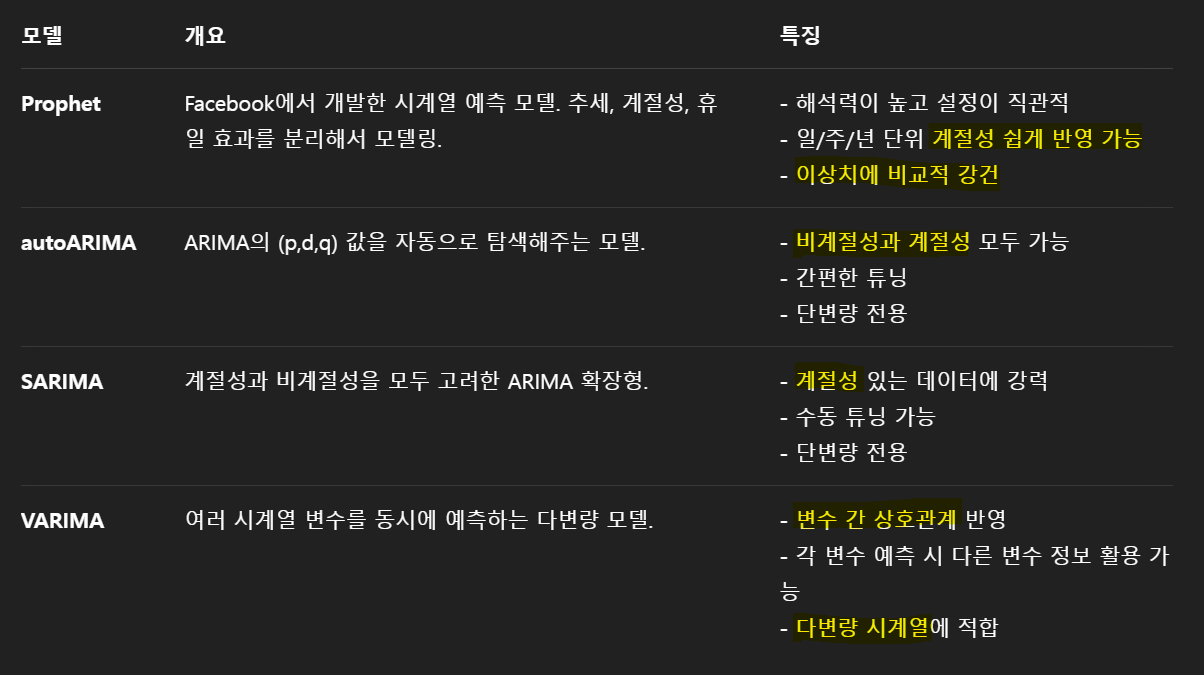

***

In [2]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [17]:
font_path = "C:/Windows/Fonts/malgun.ttf"
plt.rcParams["font.family"] = fm.FontProperties(fname=font_path).get_name()

# 한글 폰트 설정 (Windows 기준)
plt.rcParams['font.family'] = 'Malgun Gothic'
# 마이너스 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

In [4]:
from prophet import Prophet
from darts.models import VARIMA
from pmdarima import auto_arima
from darts import TimeSeries

In [5]:
df = pd.read_csv('../data/full_date_data_for_MTSF_withSmoothing.csv')
df

,date,daily_quantity_실리콘_계란찜기(소),daily_quantity_실리콘_뒤짐개,daily_quantity_실리콘_볶음주걱,daily_quantity_내열장갑,daily_quantity_실리콘_계란찜기(대),daily_quantity_실리콘_도마(대),daily_quantity_실리콘_냄비잡이,daily_quantity_실리콘_스테인리스집게(소),daily_quantity_오픈수납함,daily_quantity_실리콘_계란찜기(중),daily_quantity_실리콘_도마(중),daily_quantity_실리콘_멀티스푼,daily_quantity_실리콘_비누받침,daily_quantity_실리콘_스테인리스집게(대),daily_quantity_실리콘_다용도 오일브러쉬,daily_quantity_실리콘_덮개세트_샤크
0,2022-01-03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,184.0,0.0,0.0,0.0,0.0,40.0,0.0,0.0
1,2022-01-04,0.0,0.0,0.0,10.0,10.0,40.0,0.0,0.0,10.0,0.0,40.0,0.0,0.0,1.0,0.0,0.0
2,2022-01-05,0.0,30.0,0.0,0.0,0.0,36.0,0.0,10.0,1.0,0.0,18.0,60.0,0.0,12.0,0.0,30.0
3,2022-01-06,0.0,30.0,0.0,10.0,10.0,76.0,0.0,10.0,199.0,0.0,58.0,60.0,0.0,53.0,0.0,30.0
4,2022-01-07,0.0,30.0,30.0,10.0,10.0,76.0,0.0,10.0,25.0,0.0,58.0,77.0,0.0,13.0,0.0,30.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1089,2024-12-27,1.0,0.0,0.0,0.0,0.0,0.0,40.0,72.0,71.0,10.0,0.0,0.0,0.0,0.0,40.0,0.0
1090,2024-12-28,0.0,0.0,0.0,0.0,0.0,0.0,40.0,72.0,71.0,10.0,0.0,0.0,0.0,0.0,40.0,0.0
1091,2024-12-29,0.0,0.0,0.0,0.0,0.0,0.0,40.0,72.0,65.0,10.0,0.0,0.0,0.0,0.0,40.0,0.0
1092,2024-12-30,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,66.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1094 entries, 0 to 1093
Data columns (total 17 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   date                           1094 non-null   object 
 1   daily_quantity_실리콘_계란찜기(소)     1094 non-null   float64
 2   daily_quantity_실리콘_뒤짐개         1094 non-null   float64
 3   daily_quantity_실리콘_볶음주걱        1094 non-null   float64
 4   daily_quantity_내열장갑            1094 non-null   float64
 5   daily_quantity_실리콘_계란찜기(대)     1094 non-null   float64
 6   daily_quantity_실리콘_도마(대)       1094 non-null   float64
 7   daily_quantity_실리콘_냄비잡이        1094 non-null   float64
 8   daily_quantity_실리콘_스테인리스집게(소)  1094 non-null   float64
 9   daily_quantity_오픈수납함           1094 non-null   float64
 10  daily_quantity_실리콘_계란찜기(중)     1094 non-null   float64
 11  daily_quantity_실리콘_도마(중)       1094 non-null   float64
 12  daily_quantity_실리콘_멀티스푼        1094 non-null   f

In [7]:
df['date'] = pd.to_datetime(df['date'])
df.head(3)

,date,daily_quantity_실리콘_계란찜기(소),daily_quantity_실리콘_뒤짐개,daily_quantity_실리콘_볶음주걱,daily_quantity_내열장갑,daily_quantity_실리콘_계란찜기(대),daily_quantity_실리콘_도마(대),daily_quantity_실리콘_냄비잡이,daily_quantity_실리콘_스테인리스집게(소),daily_quantity_오픈수납함,daily_quantity_실리콘_계란찜기(중),daily_quantity_실리콘_도마(중),daily_quantity_실리콘_멀티스푼,daily_quantity_실리콘_비누받침,daily_quantity_실리콘_스테인리스집게(대),daily_quantity_실리콘_다용도 오일브러쉬,daily_quantity_실리콘_덮개세트_샤크
0,2022-01-03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,184.0,0.0,0.0,0.0,0.0,40.0,0.0,0.0
1,2022-01-04,0.0,0.0,0.0,10.0,10.0,40.0,0.0,0.0,10.0,0.0,40.0,0.0,0.0,1.0,0.0,0.0
2,2022-01-05,0.0,30.0,0.0,0.0,0.0,36.0,0.0,10.0,1.0,0.0,18.0,60.0,0.0,12.0,0.0,30.0


In [8]:
split_index = int(len(df) * 0.8)
train_df = df.iloc[:split_index]
test_df = df.iloc[split_index:]

***

# 1. Prophet
- 장점: trend + seasonality 자동 학습
- 단점: 아주 복잡한 패턴은 어려움
- 적합도: 주기성이 생겼다면 유리

## 1) 모델링 및 성능

In [9]:
def prophet_forecast_evaluate(train_df, test_df, col):
    # Prophet 형식 맞추기: 날짜 컬럼이 ds, 예측할 값이 y
    df_train = train_df[['date', col]].rename(columns={'date': 'ds', col: 'y'})
    df_test = test_df[['date', col]].rename(columns={'date': 'ds', col: 'y'})

    # Prophet 모델 객체 생성 후 학습 데이터를 사용해 훈련
    model = Prophet()
    model.fit(df_train)

    # 학습이 끝나고, 예측할 날짜만 넘기면 Prophet이 해당 날짜에 대한 예측값(yhat)을 자동으로 생성
    future = df_test[['ds']]
    forecast_test = model.predict(future)

    # 예측 결과
    y_pred = forecast_test['yhat'].values # Prophet의 예측값 (yhat)
    y_true = df_test['y'].values # y_true: 테스트 데이터의 실제 관측값

    # 성능 지표
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)

    # Naive 모델 비교용 (shift로 한 시점 앞 값 사용)
    # .shift(1)은 데이터를 아래로 1칸 이동시킴
    # .dropna()로 맨 앞의 NaN을 제거: 길이 동일해야함
    naive_forecast = train_df[col].shift(1).dropna().values # 이전 시점의 값을 그대로 예측
    naive_actual = train_df[col][1:].values # 실제로 관측된 값, 이는 한 칸 뒤의 값들

    # Naive 기반 MASE, RMSSE 계산: Naive 모델이 어느 정도 정확한가
    mase_denom = np.mean(np.abs(naive_actual - naive_forecast))
    rmsse_denom = np.sqrt(np.mean((naive_actual - naive_forecast) ** 2))

    # 모델 성능 / Naive 성능
    mase = mae / mase_denom if mase_denom != 0 else np.nan
    rmsse = rmse / rmsse_denom if rmsse_denom != 0 else np.nan

    return forecast_test[['ds', 'yhat']], rmsse, mase

In [10]:
# 예측하고 싶은 컬럼들의 리스트
target_cols = [col for col in train_df.columns if col.startswith('daily_quantity_')]

In [11]:
# 결과 저장
all_forecasts = [] # 예측 결과를 저장할 리스트
rmsse_results = {} # 컬럼별 RMSSE 값을 저장할 딕셔너리
mase_results = {} # 컬럼별 MASE 값을 저장할 딕셔너리

for col in target_cols: # 예측할 각 컬럼에 대해 Prophet 실행
    forecast, rmsse, mase = prophet_forecast_evaluate(train_df, test_df, col)
    forecast = forecast.rename(columns={'yhat': f'forecast_{col}'}) # Prophet의 예측 결과 컬럼은 기본적으로 yhat -> 품목 구분 위해 forecast_item1 식으로 변경
    all_forecasts.append(forecast)

    rmsse_results[col] = rmsse
    mase_results[col] = mase

21:47:55 - cmdstanpy - INFO - Chain [1] start processing
21:47:55 - cmdstanpy - INFO - Chain [1] done processing
21:47:55 - cmdstanpy - INFO - Chain [1] start processing
21:47:55 - cmdstanpy - INFO - Chain [1] done processing
21:47:56 - cmdstanpy - INFO - Chain [1] start processing
21:47:56 - cmdstanpy - INFO - Chain [1] done processing
21:47:56 - cmdstanpy - INFO - Chain [1] start processing
21:47:56 - cmdstanpy - INFO - Chain [1] done processing
21:47:57 - cmdstanpy - INFO - Chain [1] start processing
21:47:57 - cmdstanpy - INFO - Chain [1] done processing
21:47:57 - cmdstanpy - INFO - Chain [1] start processing
21:47:57 - cmdstanpy - INFO - Chain [1] done processing
21:47:58 - cmdstanpy - INFO - Chain [1] start processing
21:47:58 - cmdstanpy - INFO - Chain [1] done processing
21:47:58 - cmdstanpy - INFO - Chain [1] start processing
21:47:58 - cmdstanpy - INFO - Chain [1] done processing
21:47:59 - cmdstanpy - INFO - Chain [1] start processing
21:47:59 - cmdstanpy - INFO - Chain [1]

In [12]:
# 각 지표에 대해 전체 평균값을 계산
avg_rmsse = sum(rmsse_results.values()) / len(rmsse_results)
avg_mase = sum(mase_results.values()) / len(mase_results)

# 전체적인 성능 출력
print("=== Prophet 전체 모델링 성능 ===")
print(f"전체 RMSSE 평균: {avg_rmsse:.2f}")
print(f"전체 MASE 평균: {avg_mase:.2f}")

=== Prophet 전체 모델링 성능 ===
전체 RMSSE 평균: 1.06
전체 MASE 평균: 3.02


## 2) 시각화

In [13]:
def plot_forecast_result1(test_df, forecast_df, col):
    # 예측값 병합: 실제 데이터와 예측 데이터를 date 기준으로 합침
    # 두 데이터프레임의 날짜 컬럼명이 다름 -> left_on에 열이름A, right_on에 열이름B
    plot_df = pd.merge(test_df[['date', col]], forecast_df, how='left', left_on='date', right_on='ds')

    plt.figure(figsize=(12, 5))
    plt.plot(plot_df['date'], plot_df[col], label='Actual (Test)', marker='o')
    plt.plot(plot_df['date'], plot_df[f'forecast_{col}'], label='Predicted (Prophet)', linestyle='--')
    
    plt.title(f'{col} (Actual vs Forecast)')
    plt.xlabel('Date')
    plt.ylabel('Quantity')
    
    plt.legend() # 범례 표시
    plt.grid(True) # 배경 격자 표시
    plt.tight_layout() # 레이아웃 자동 조정
    
    plt.show()

In [14]:
def plot_all_forecasts1(test_df, all_forecasts, target_cols):
    for col, forecast_df in zip(target_cols, all_forecasts):
        # 컬럼명에 맞게 예측 결과 컬럼명 변경
        # Prophet은 예측값을 항상 'yhat'이라는 컬럼에 저장 -> 컬럼명을 "forecast_품목"명으로 변경
        forecast_df = forecast_df.rename(columns={'yhat': f'forecast_{col}'}) if 'yhat' in forecast_df.columns else forecast_df
        
        print(f"품목: {col}")
        plot_forecast_result1(test_df, forecast_df, col)

품목: daily_quantity_실리콘_계란찜기(소)


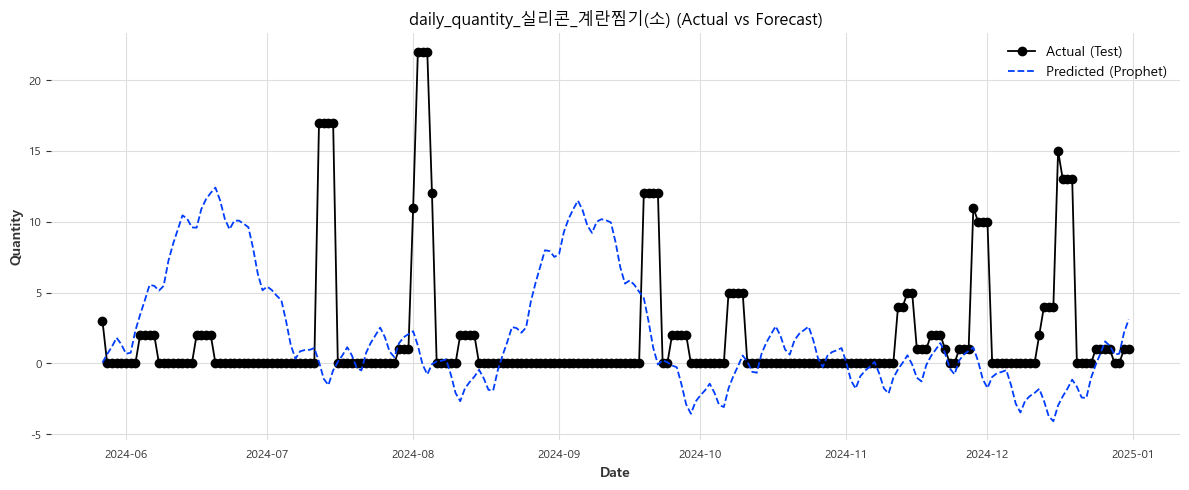

품목: daily_quantity_실리콘_뒤짐개


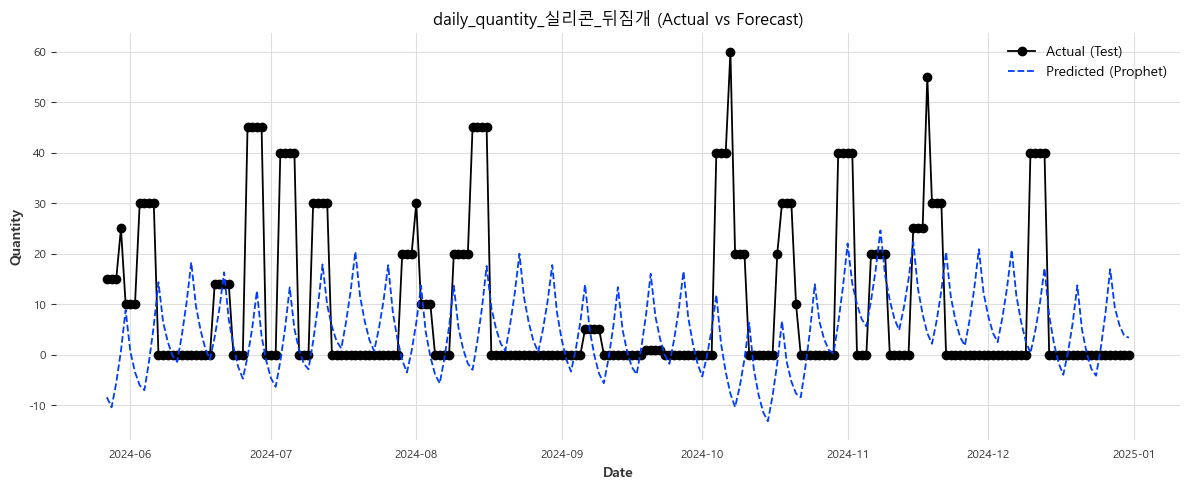

품목: daily_quantity_실리콘_볶음주걱


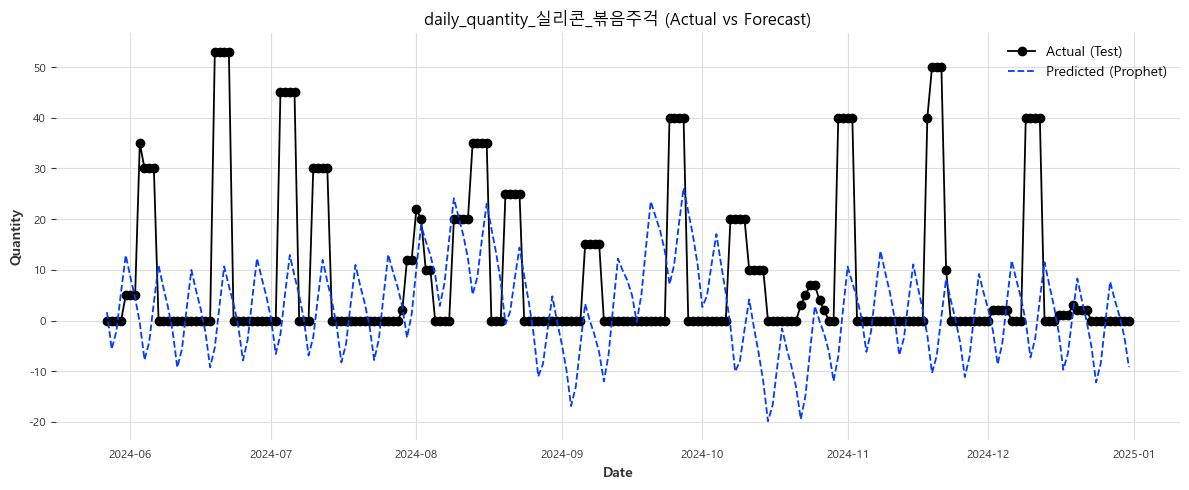

품목: daily_quantity_내열장갑


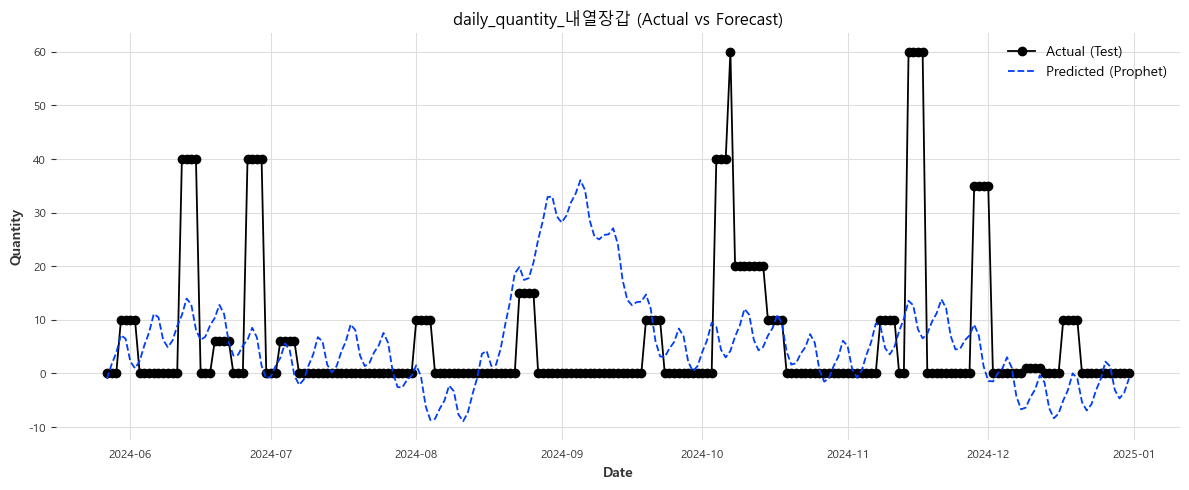

품목: daily_quantity_실리콘_계란찜기(대)


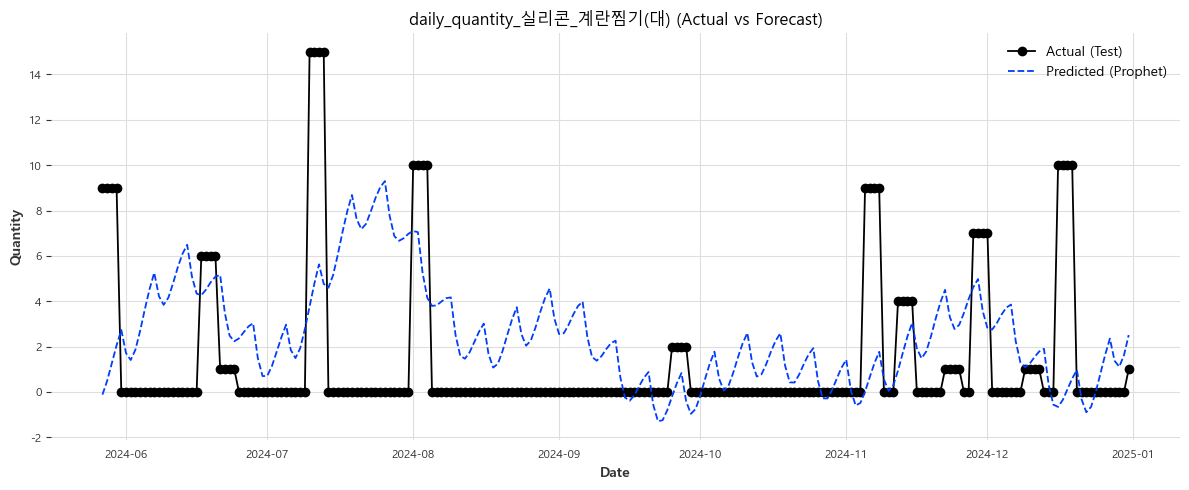

품목: daily_quantity_실리콘_도마(대)


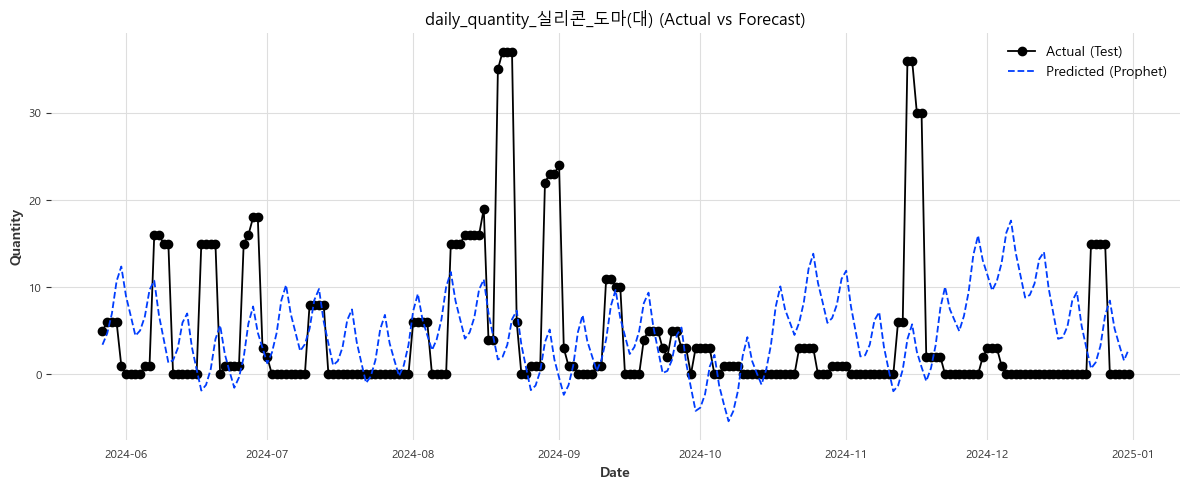

품목: daily_quantity_실리콘_냄비잡이


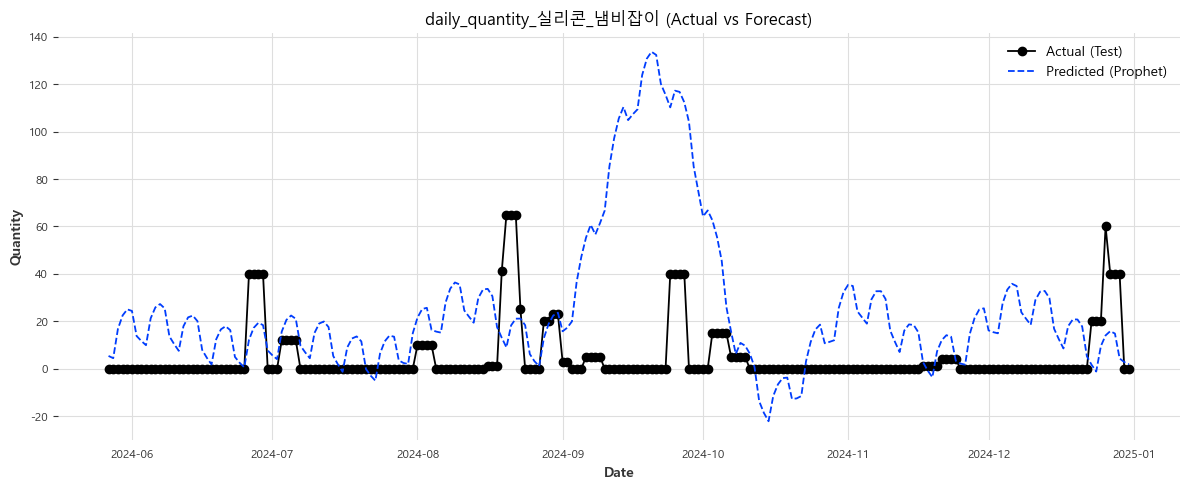

품목: daily_quantity_실리콘_스테인리스집게(소)


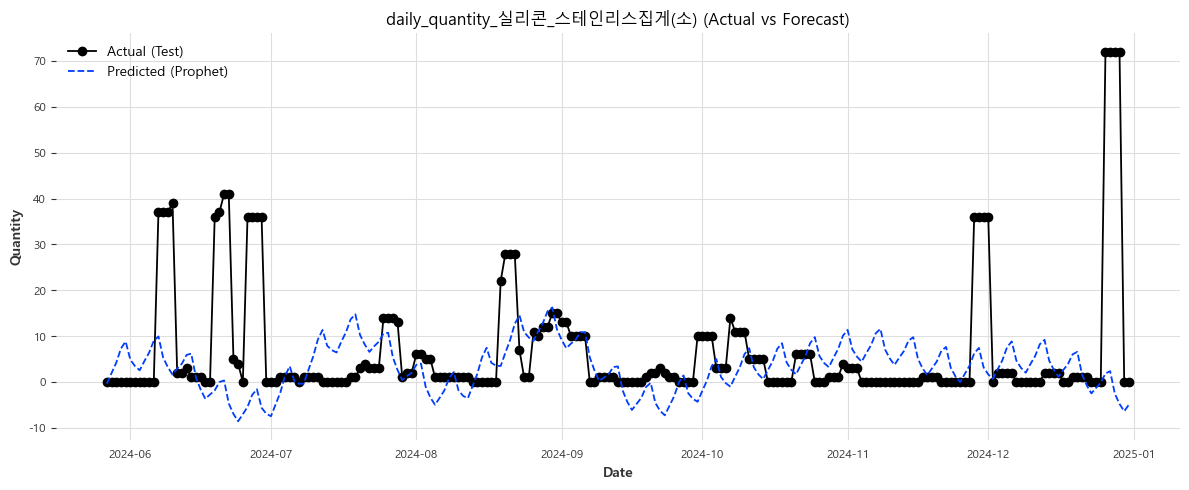

품목: daily_quantity_오픈수납함


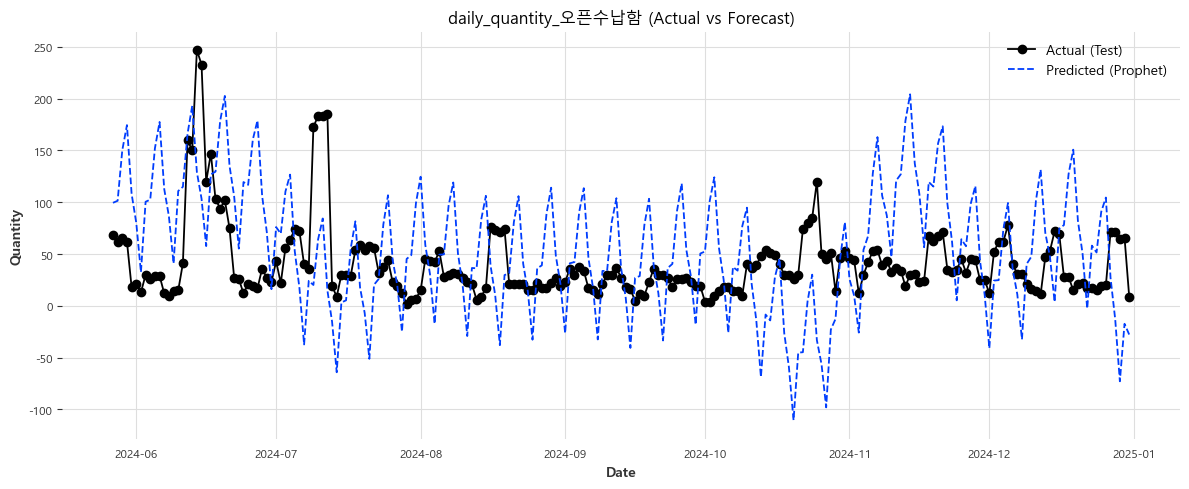

품목: daily_quantity_실리콘_계란찜기(중)


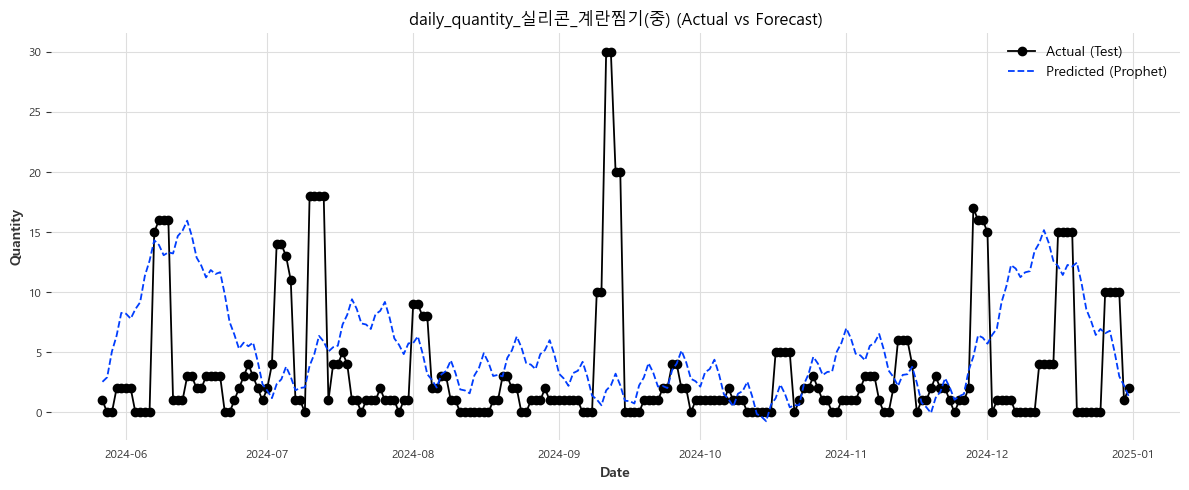

품목: daily_quantity_실리콘_도마(중)


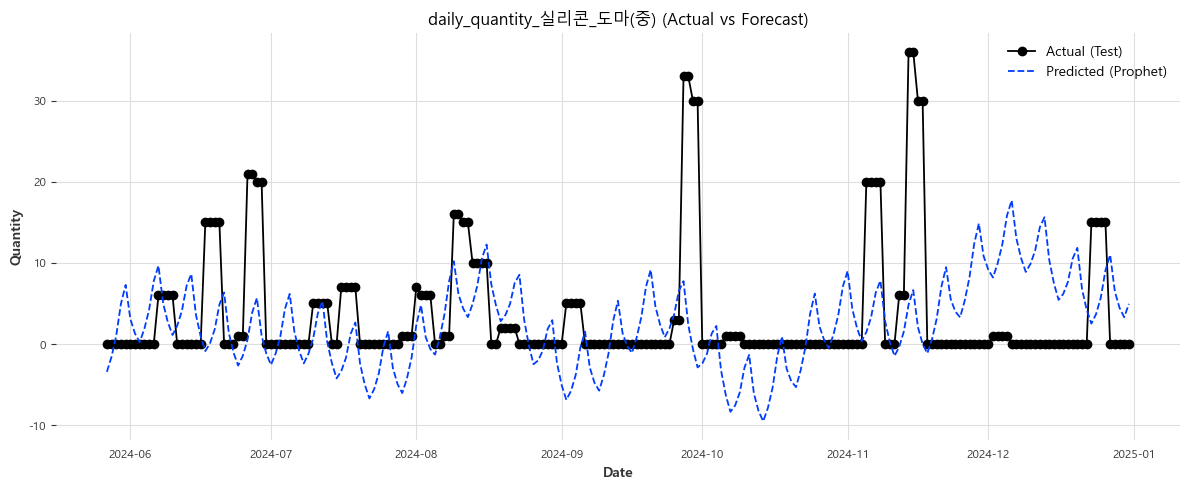

품목: daily_quantity_실리콘_멀티스푼


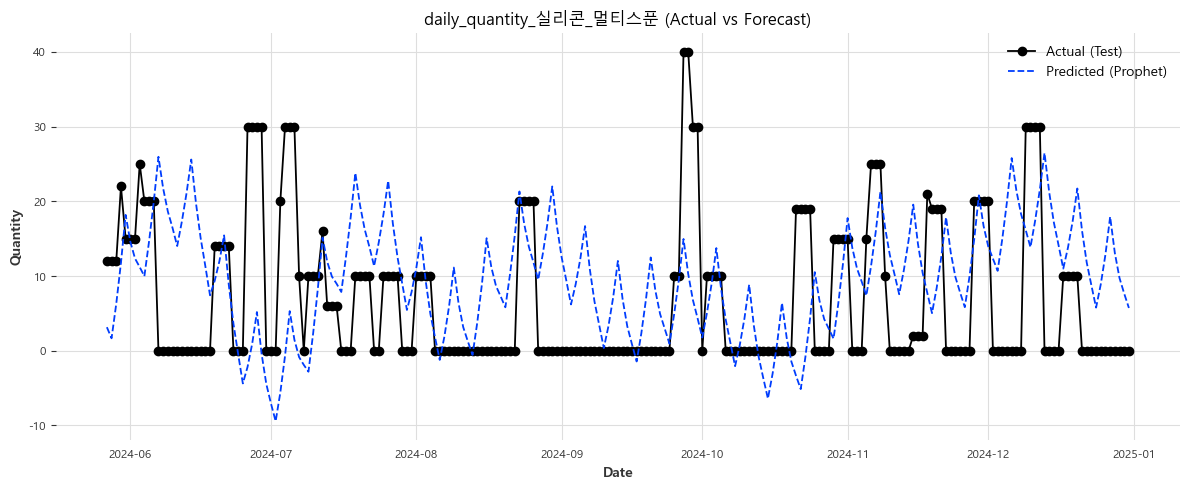

품목: daily_quantity_실리콘_비누받침


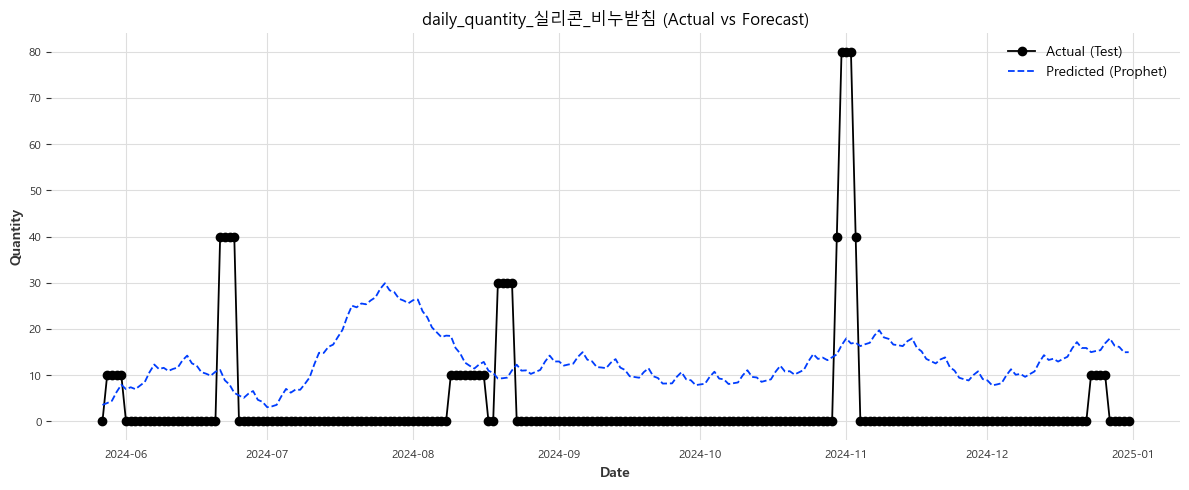

품목: daily_quantity_실리콘_스테인리스집게(대)


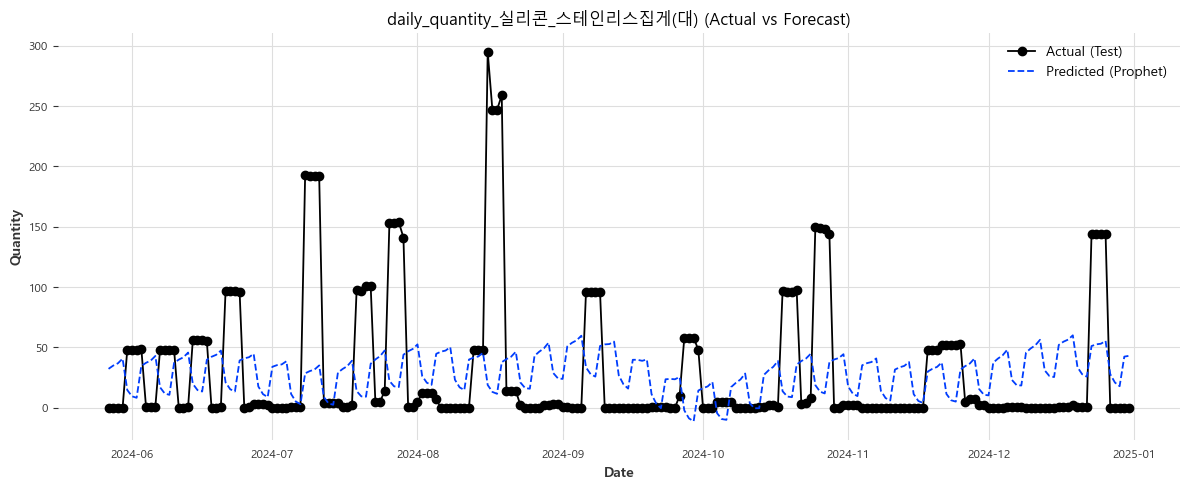

품목: daily_quantity_실리콘_다용도 오일브러쉬


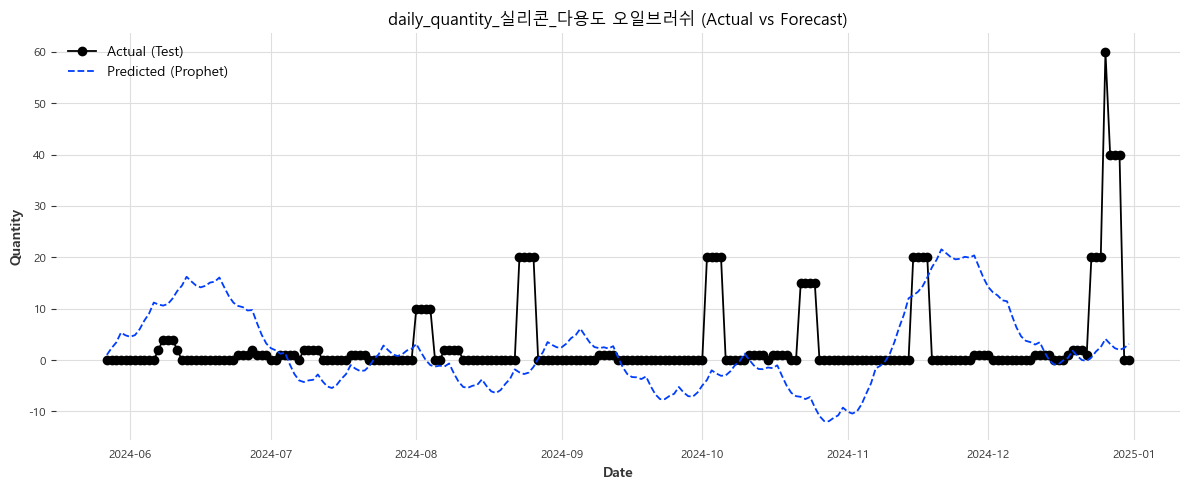

품목: daily_quantity_실리콘_덮개세트_샤크


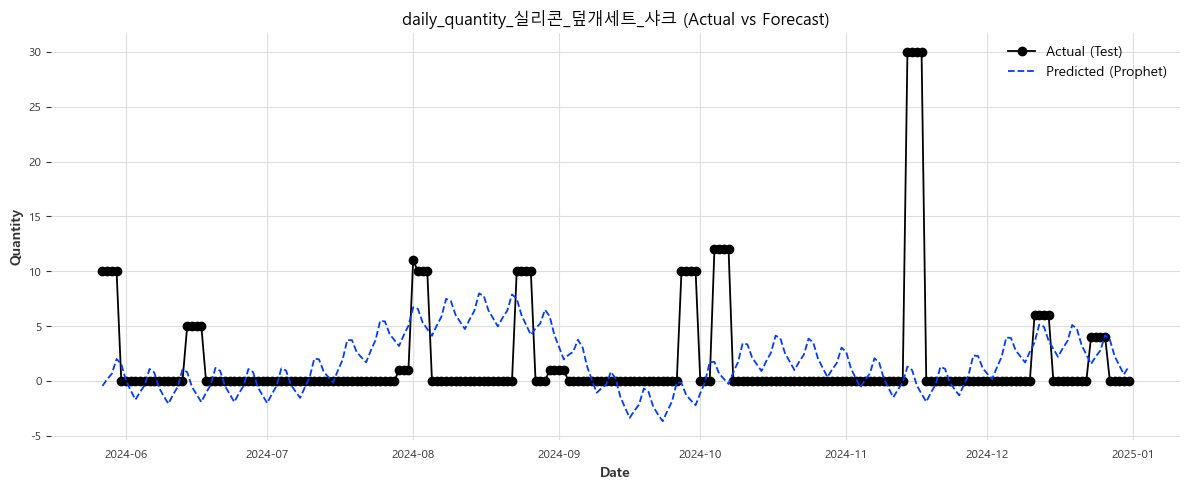

In [18]:
plot_all_forecasts1(test_df, all_forecasts, target_cols)

***

# 2. VARIMA
- 여러 품목 간 연관성(상관성)이 있다면 유리
- → 예: A, B 품목 수요가 같이 움직일 때

In [19]:
# 시계열 객체로 변환 (date를 인덱스로 설정)
series = TimeSeries.from_dataframe(df, time_col='date')
# series

## 1) 모델링 및 성능

In [20]:
data = df.copy()

# 컬럼 정규화
target_cols = data.columns.drop('date')
scaler = StandardScaler()
scaled = scaler.fit_transform(data[target_cols])
scaled_df = pd.DataFrame(scaled, columns=target_cols)
scaled_df['date'] = data['date'].values

# TimeSeries 객체로 변환
series = TimeSeries.from_dataframe(scaled_df, time_col='date')

# 데이터 분할
train_size = int(len(series) * 0.8)
train_series = series[:train_size]
test_series = series[train_size:]

In [21]:
model = VARIMA(1, 0, 0) # 기본 설정
model.fit(train_series)
forecast = model.predict(len(test_series))

In [22]:
# 평가 지표 계산
y_pred = forecast.values()
y_true = test_series.values()
y_train = train_series.values()

# naive 예측 (1-step 시차 naive)
naive_forecast = y_train[:-1]
naive_actual = y_train[1:]

# MASE, RMSSE 계산
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

mase_denom = np.mean(np.abs(naive_actual - naive_forecast))
rmsse_denom = np.sqrt(np.mean((naive_actual - naive_forecast) ** 2))

mase = mae / mase_denom if mase_denom != 0 else np.nan
rmsse = rmse / rmsse_denom if rmsse_denom != 0 else np.nan

# 결과 출력
print("=== VARIMA 모델 성능 (전체 상품 컬럼 기준) ===")
print(f"MASE  : {mase:.2f}")
print(f"RMSSE : {rmsse:.2f}")

=== VARIMA 모델 성능 (전체 상품 컬럼 기준) ===
MASE  : 2.23
RMSSE : 0.94


## 2) 시각화

In [23]:
# 정규화한 것 역변환
y_true = scaler.inverse_transform(y_true)
y_pred = scaler.inverse_transform(y_pred)

In [24]:
y_pred

array([[ 2.95102717,  4.04427372,  2.01513467, ..., 10.3040938 ,
         1.41151453,  0.7270914 ],
       [ 2.93405489,  7.46009859,  4.21501097, ..., 16.98320448,
         2.29694416,  1.2758646 ],
       [ 2.9217035 , 10.22170852,  6.34269253, ..., 21.17659937,
         2.83307534,  1.68598526],
       ...,
       [ 2.67458867, 17.15539305, 15.83180987, ..., 25.82723949,
         2.91407678,  2.7202925 ],
       [ 2.67458867, 17.15539305, 15.83180987, ..., 25.82723949,
         2.91407678,  2.7202925 ],
       [ 2.67458867, 17.15539305, 15.83180987, ..., 25.82723949,
         2.91407678,  2.7202925 ]])

In [25]:
def plot_varima_forecast_restored(y_true, y_pred, test_series, target_cols):
    date_index = test_series.time_index

    # 예측값과 실제값을 컬럼명으로 데이터프레임화
    df_true = pd.DataFrame(y_true, columns=target_cols)
    df_pred = pd.DataFrame(y_pred, columns=target_cols)
    df_true['date'] = date_index
    df_pred['date'] = date_index

    # Prophet 스타일 시각화
    for col in target_cols:
        plot_df = pd.merge(df_true[['date', col]],
                           df_pred[['date', col]].rename(columns={col: f'forecast_{col}'}),
                           on='date', how='left')

        plt.figure(figsize=(12, 5))
        plt.plot(plot_df['date'], plot_df[col], label='Actual (Test)', marker='o')
        plt.plot(plot_df['date'], plot_df[f'forecast_{col}'], label='Predicted (VARIMA)', linestyle='--')

        plt.title(f'{col} (Actual vs Forecast - VARIMA)')
        plt.xlabel('Date')
        plt.ylabel('수량')
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.xticks(rotation=45)
        plt.show()

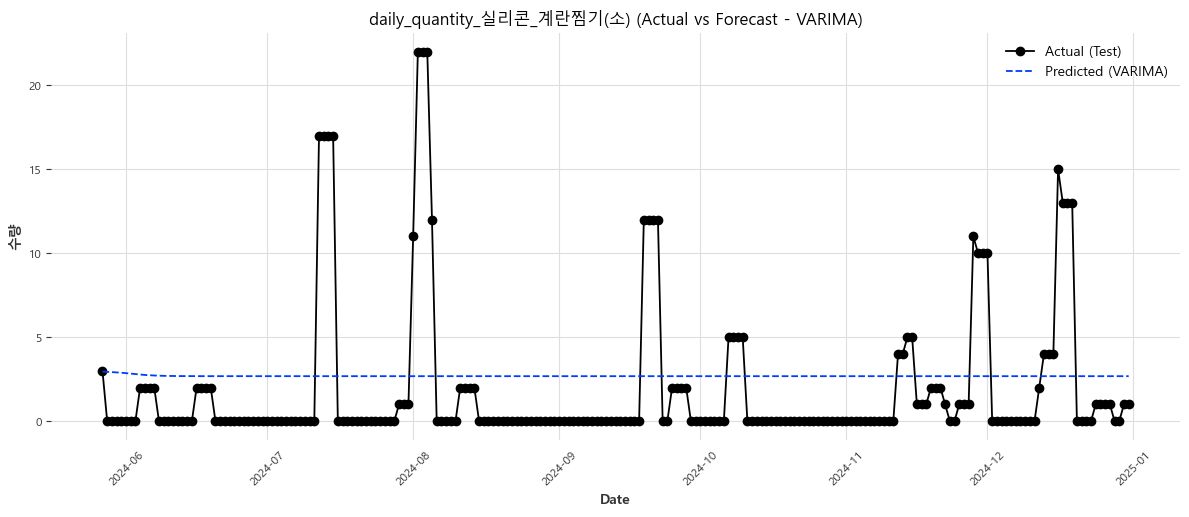

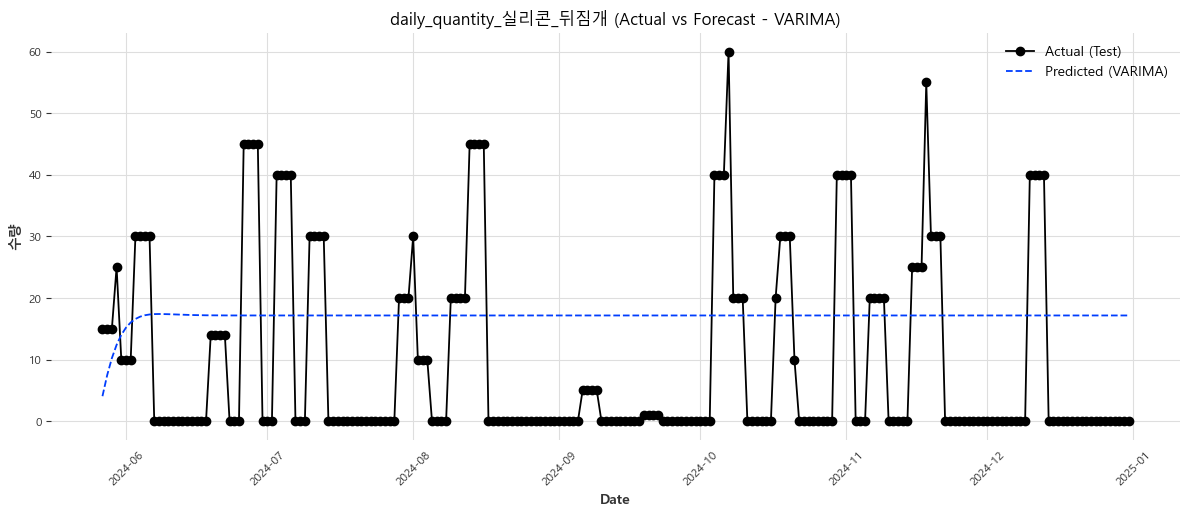

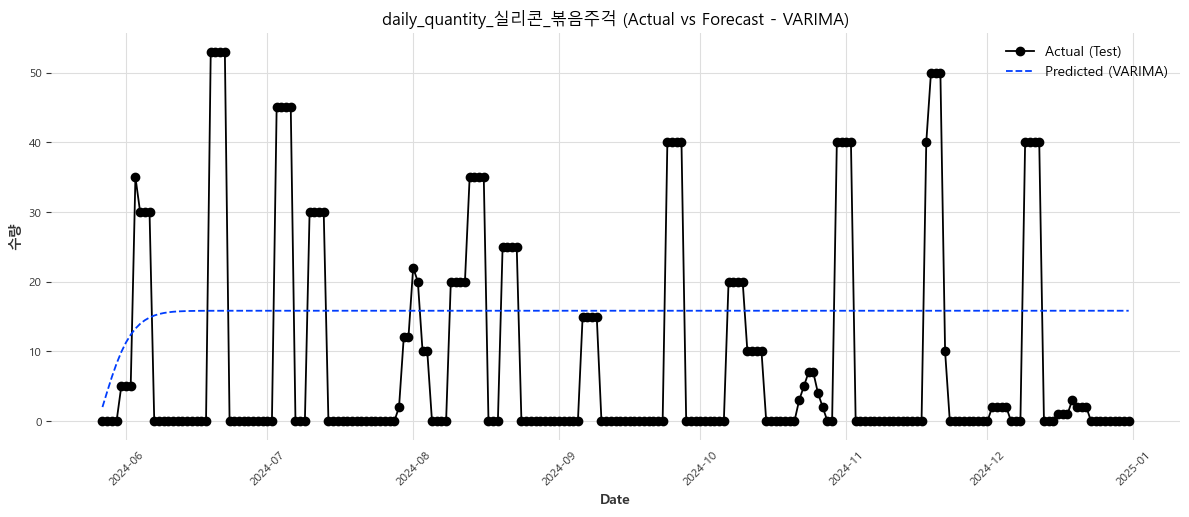

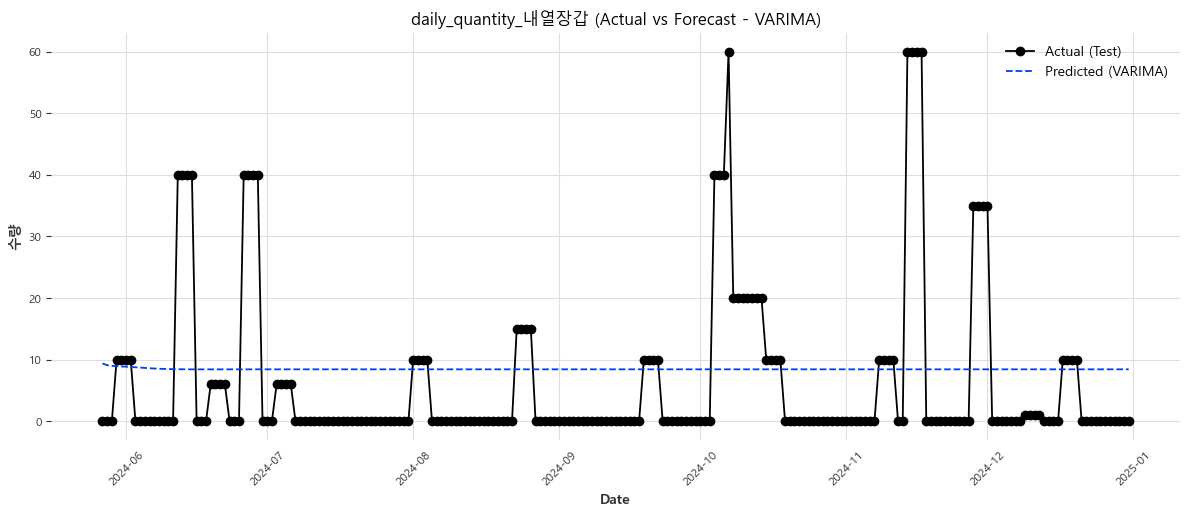

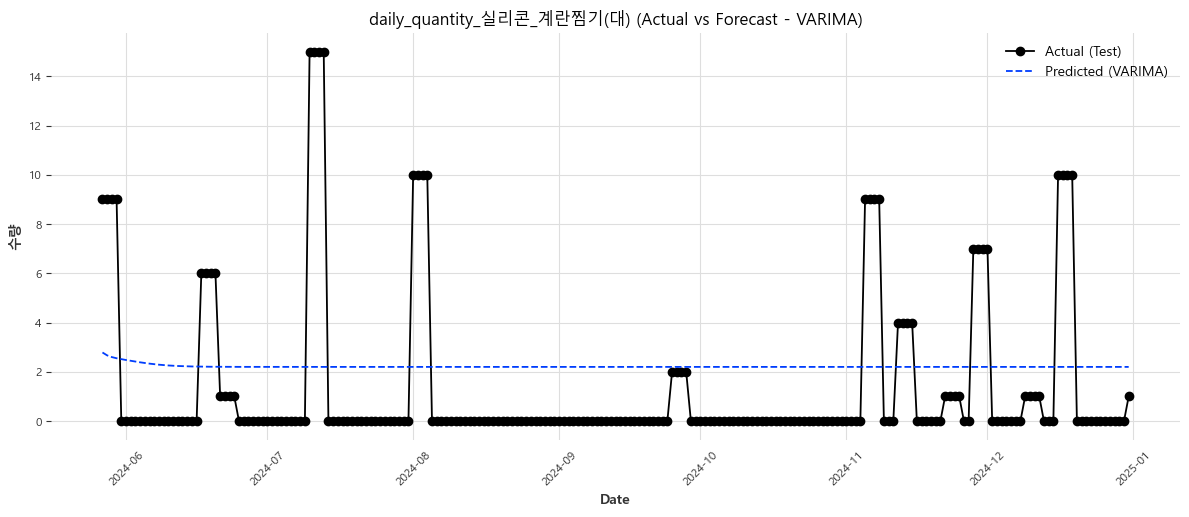

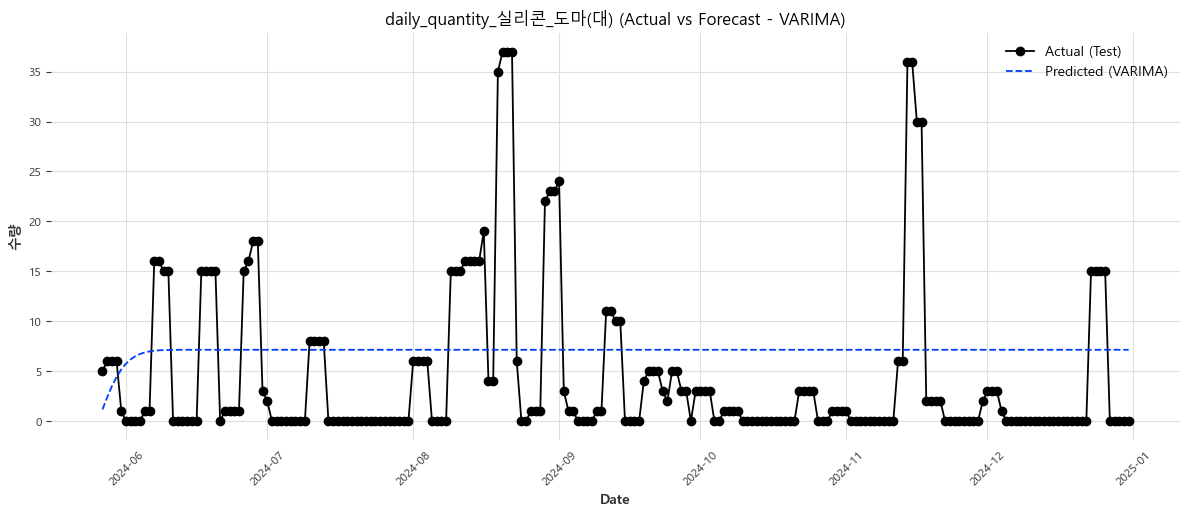

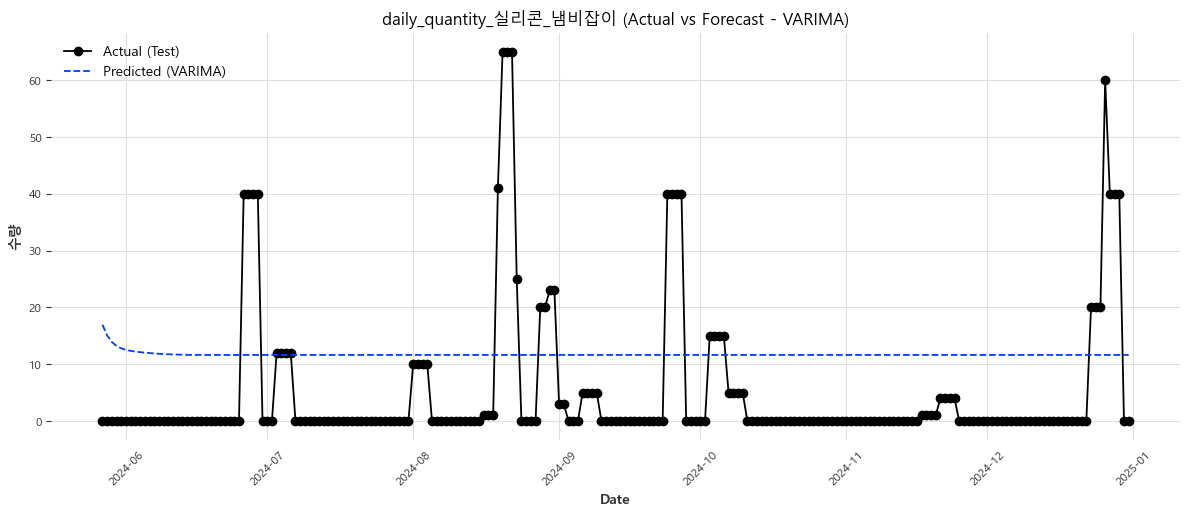

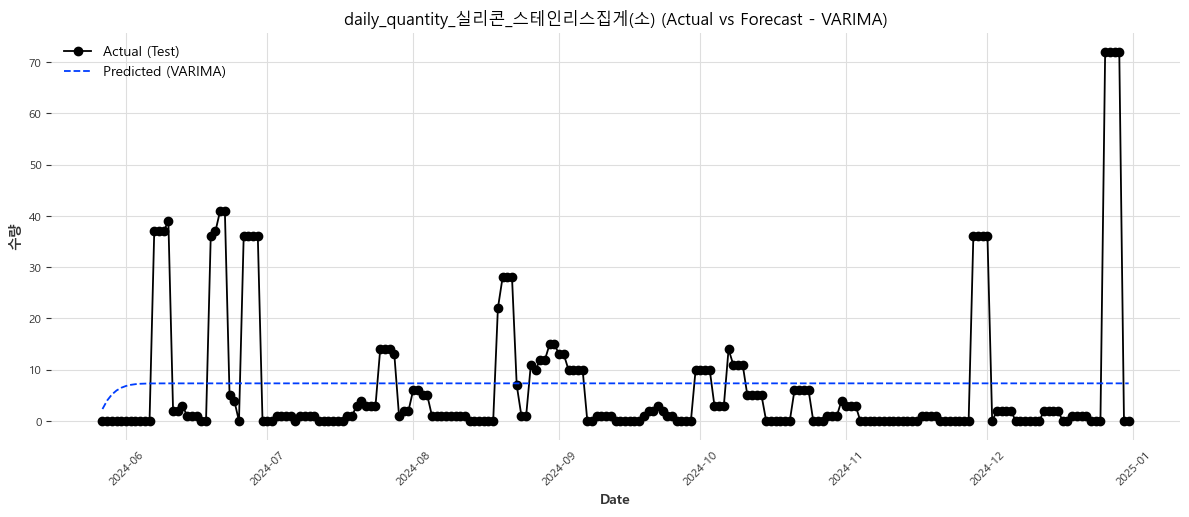

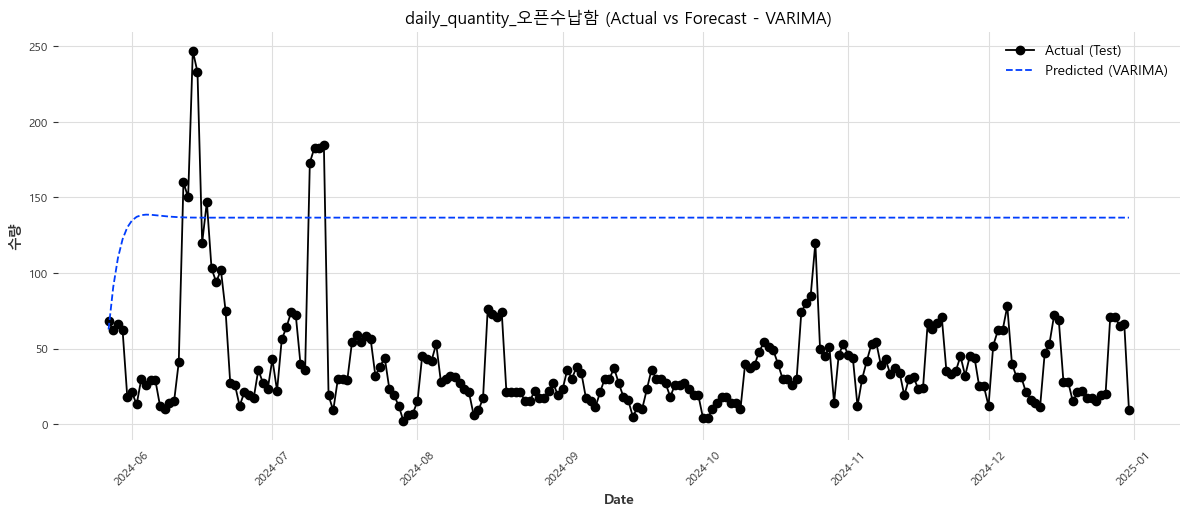

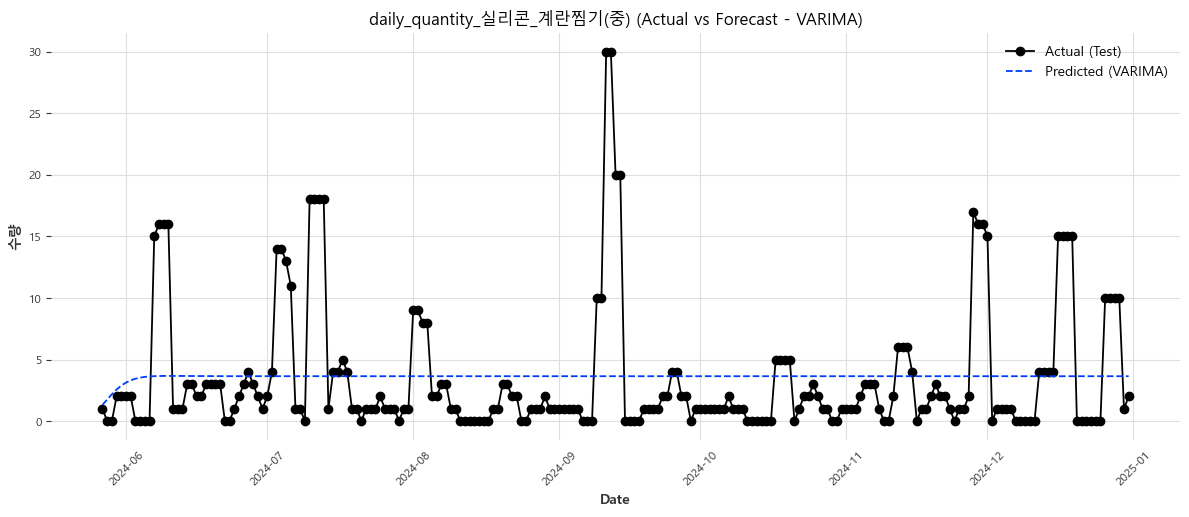

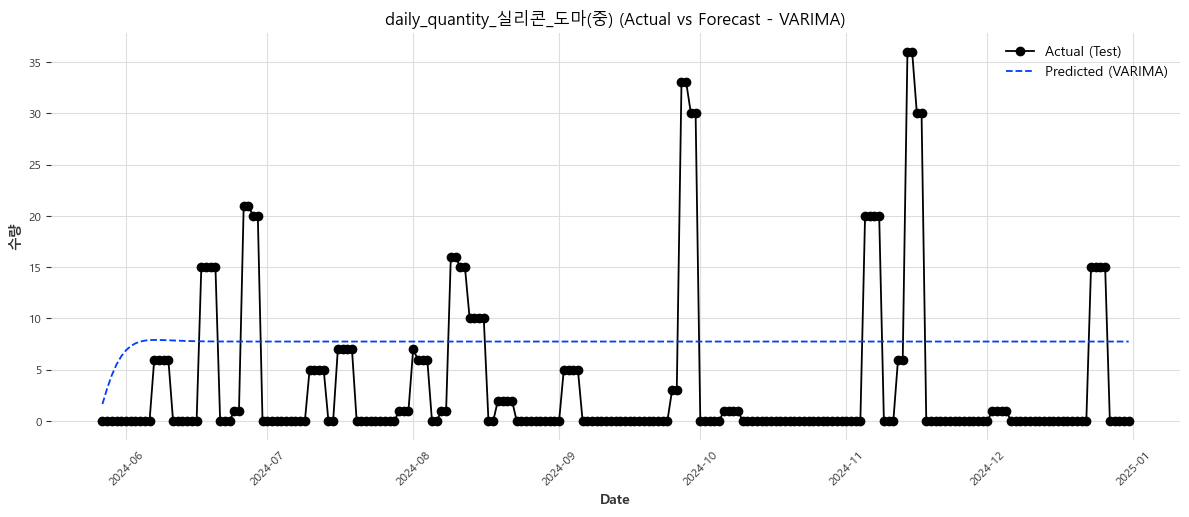

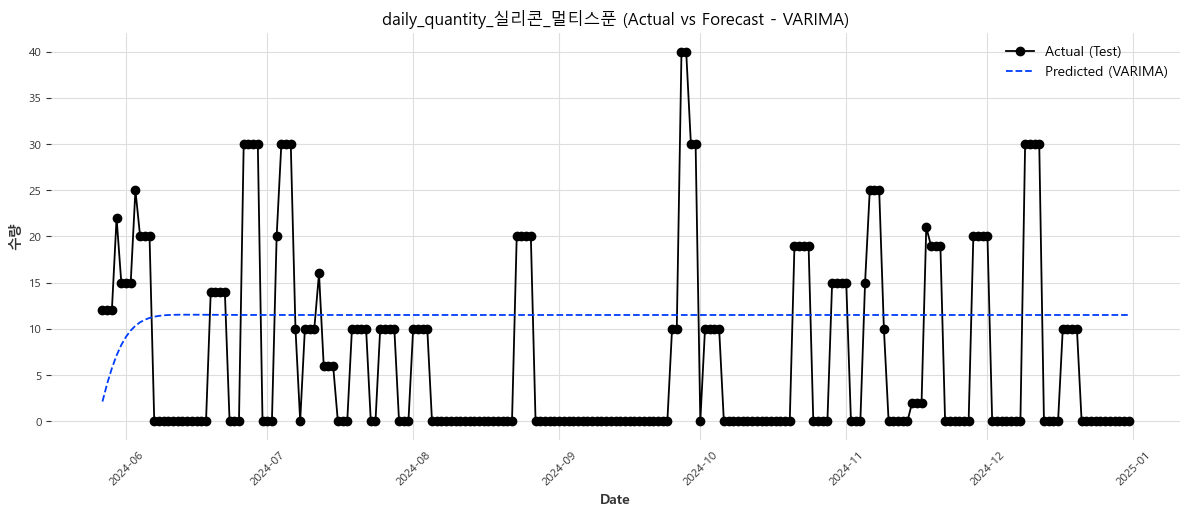

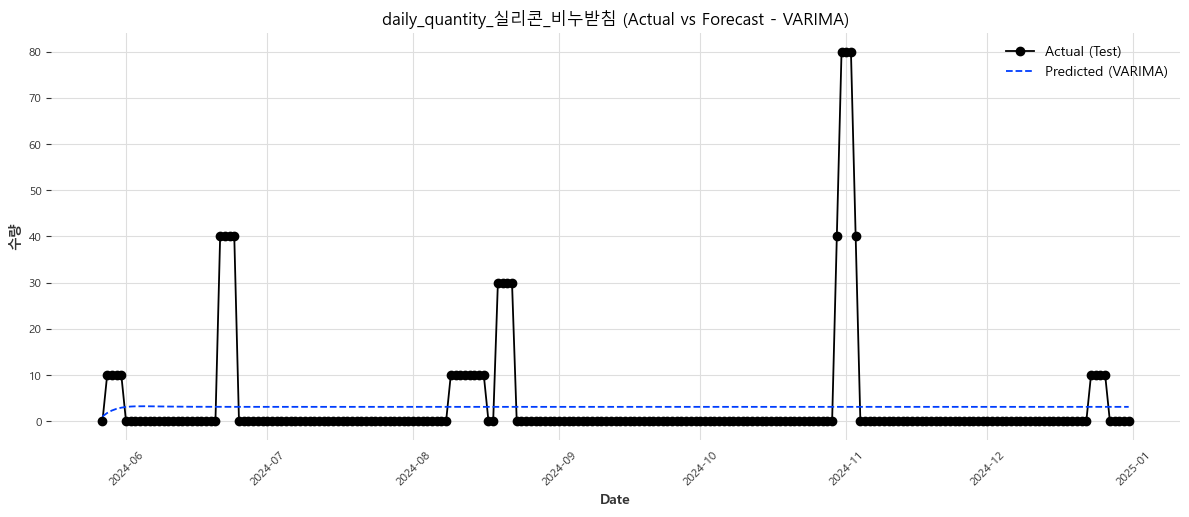

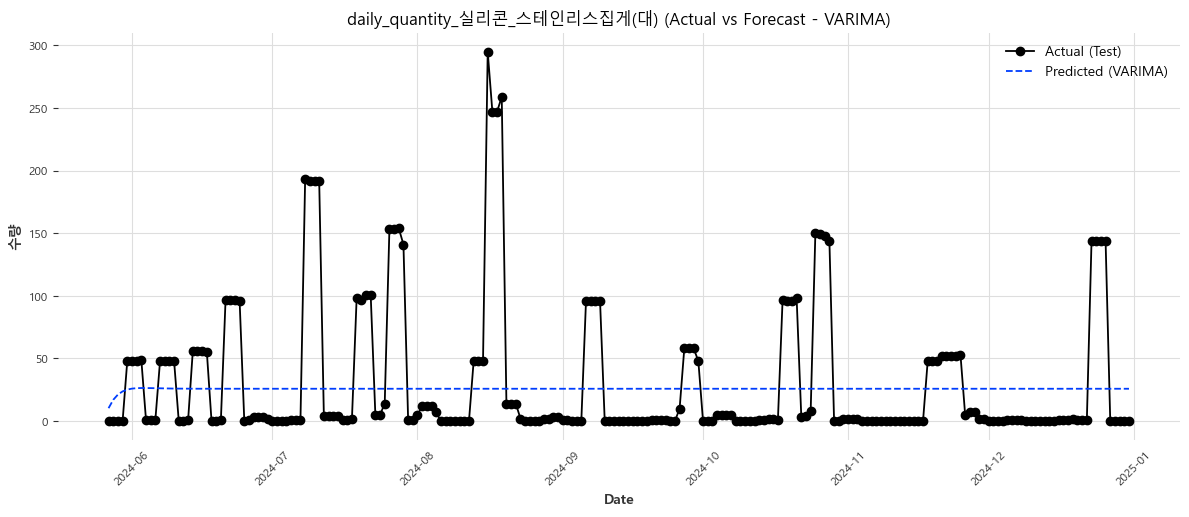

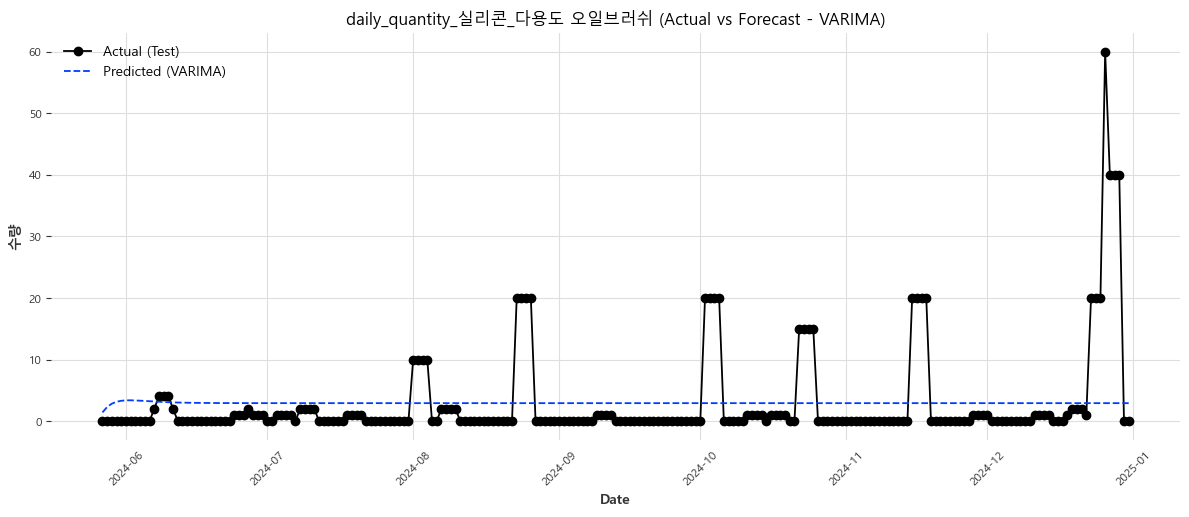

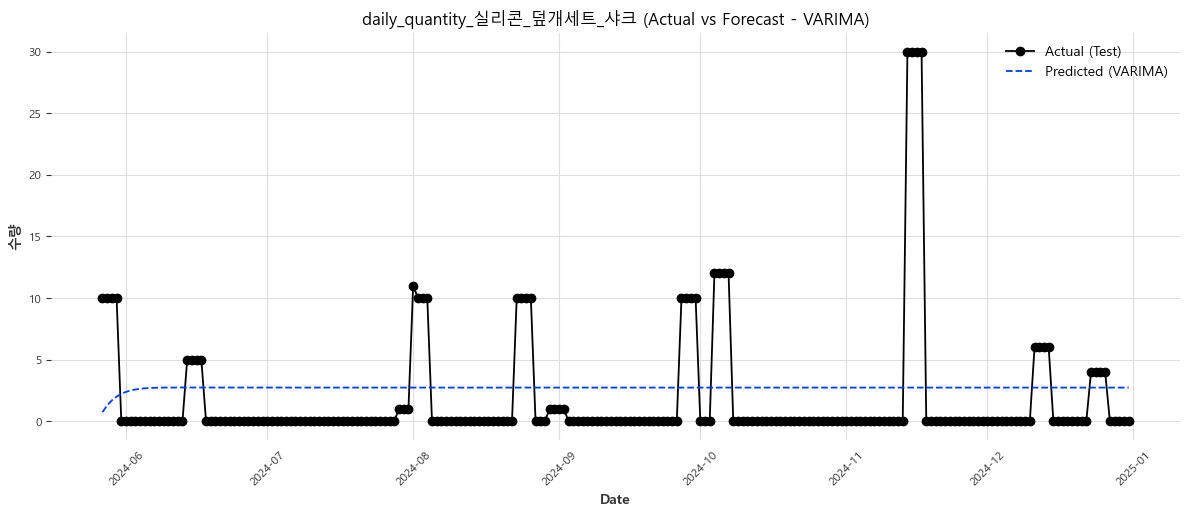

In [26]:
plot_varima_forecast_restored(y_true, y_pred, test_series, target_cols)

## 3. AutoARIMA & SARIMA
- 기존 시계열 모형의 자동화된 버전
- Seasonality가 있다면 SARIMA가 좋음

In [27]:
# index를 reset 해서 date 컬럼 복원
df.reset_index(inplace=True)

# 다시 date를 인덱스로 설정하고 datetime 형식으로 변환
df.set_index('date', inplace=True)
df.index = pd.to_datetime(df.index)

## 3-1. AutoARIMA

In [28]:
# 예측 결과 저장할 dict
y_test_dict = {}
y_pred_dict = {}

for col in target_cols:
    y_train = train_df[col]
    y_test = test_df[col]
    
    model = auto_arima(y_train, seasonal=True, m=12, stepwise=True, suppress_warnings=True)
    forecast = model.predict(n_periods=len(y_test))

    y_test_dict[col] = y_test
    y_pred_dict[col] = forecast

C:\Users\jwoo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\jwoo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\jwoo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\jwoo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\jwoo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprec

In [29]:
y_pred_dict

{'daily_quantity_실리콘_계란찜기(소)': 875     2.494225
 876     0.668158
 877     0.177348
 878     2.663194
 879     2.957128
           ...   
 1089    2.863814
 1090    2.863814
 1091    2.863814
 1092    2.863814
 1093    2.863814
 Length: 219, dtype: float64,
 'daily_quantity_실리콘_뒤짐개': 875     0.036872
 876     0.036866
 877     0.211521
 878     0.211521
 879    -0.840583
           ...   
 1089    0.047282
 1090    0.047282
 1091    0.047282
 1092    0.047282
 1093    0.047282
 Length: 219, dtype: float64,
 'daily_quantity_실리콘_볶음주걱': 875    -1.576333
 876    -1.700574
 877    -1.710366
 878    -1.711138
 879    -1.711199
           ...   
 1089   -1.711204
 1090   -1.711204
 1091   -1.711204
 1092   -1.711204
 1093   -1.711204
 Length: 219, dtype: float64,
 'daily_quantity_내열장갑': 875     5.772608
 876     5.252489
 877     3.690431
 878     7.260029
 879     7.591948
           ...   
 1089    8.909178
 1090    8.909178
 1091    8.909178
 1092    8.909178
 1093    8.909178
 Length: 219

### 시각화

In [30]:
test_index = test_df.index

In [31]:
def plot_autoarima_forecast(y_test_dict, y_pred_dict, test_index, target_cols):
    # y_test_dict: {col: 시리즈}
    # y_pred_dict: {col: 예측 array}
    
    for col in target_cols:
        actual = pd.Series(y_test_dict[col].values, index=test_index)
        predicted = pd.Series(y_pred_dict[col], index=test_index)

        # Prophet 스타일 DataFrame 병합
        plot_df = pd.DataFrame({
            'date': test_index,
            'actual': actual.values,
            'predicted': predicted.values
        })

        plt.figure(figsize=(12, 5))
        plt.plot(plot_df['date'], plot_df['actual'], label='Actual (Test)', marker='o')
        plt.plot(plot_df['date'], plot_df['predicted'], label='Predicted (autoARIMA)', linestyle='--', color='red')

        plt.title(f'{col} (Actual vs Forecast - autoARIMA)')
        plt.xlabel('Date')
        plt.ylabel('수량')
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.xticks()
        plt.show()

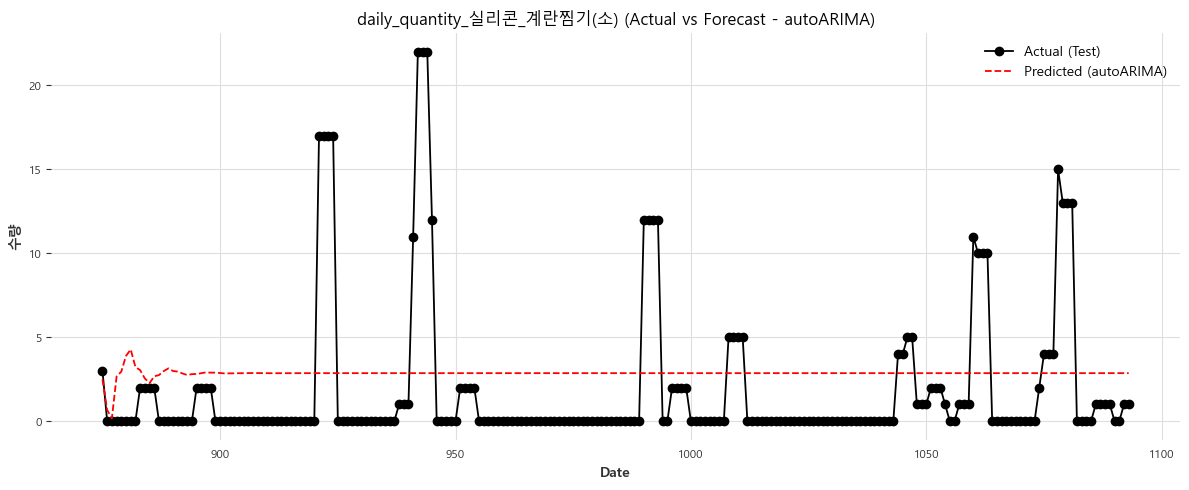

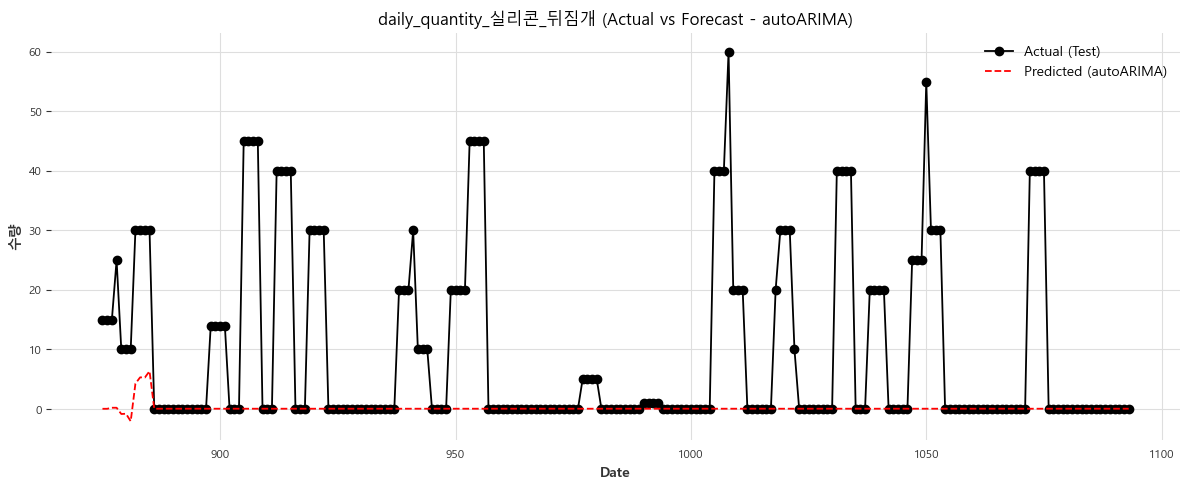

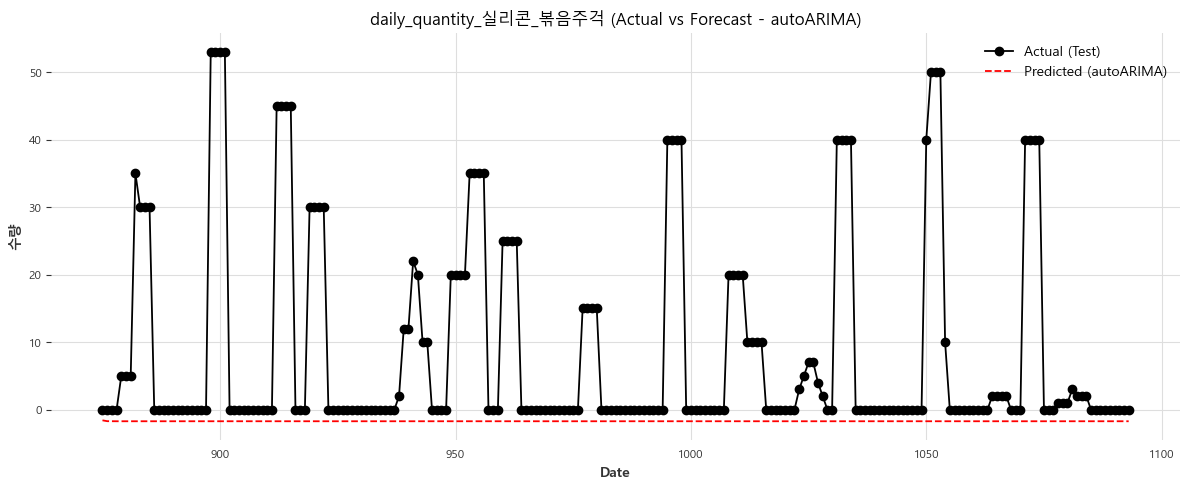

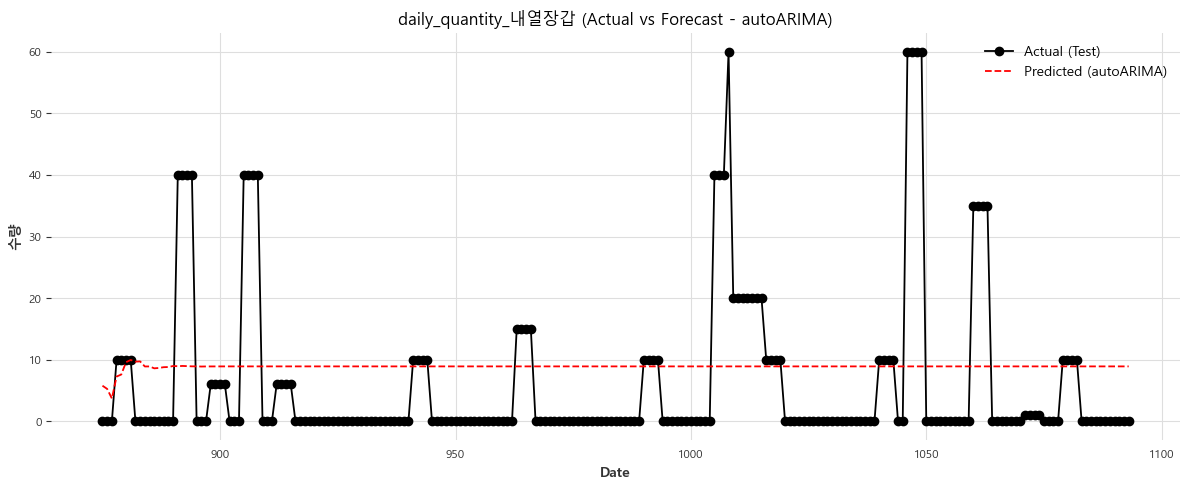

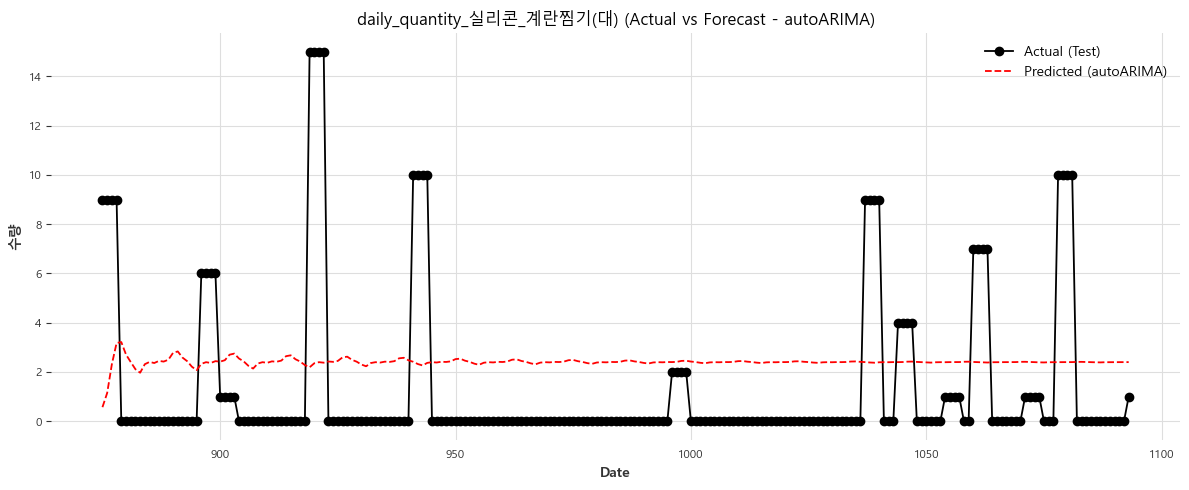

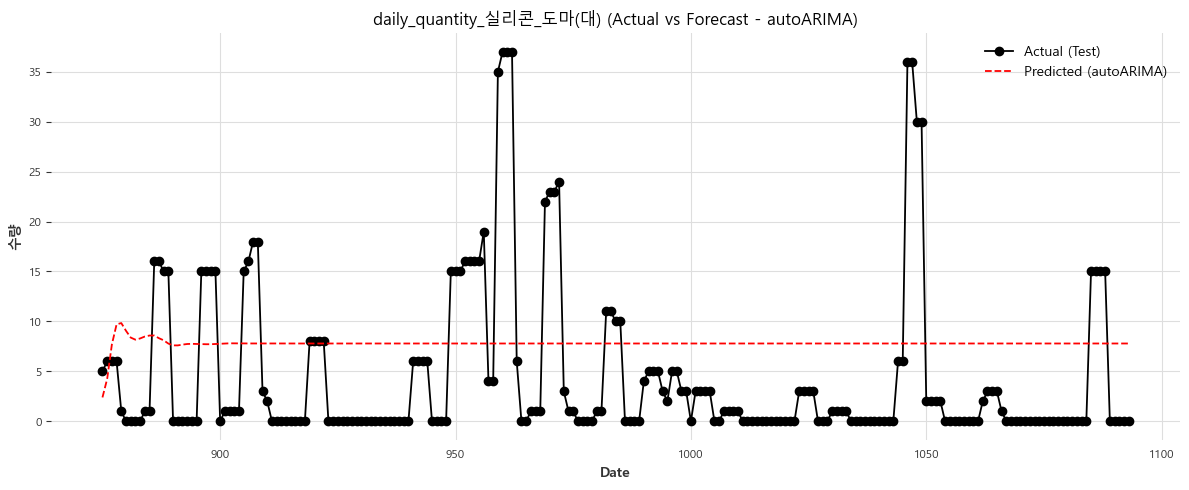

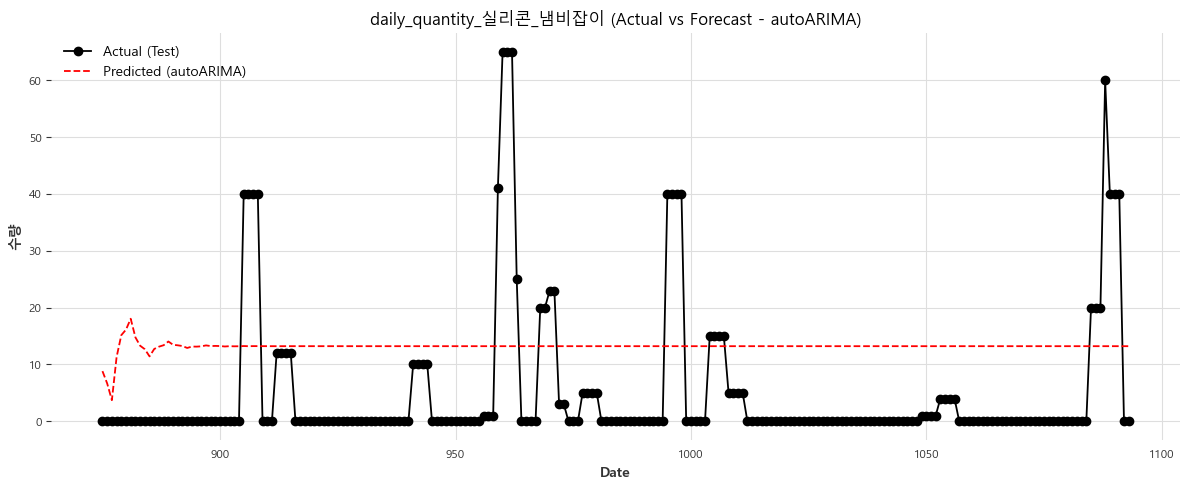

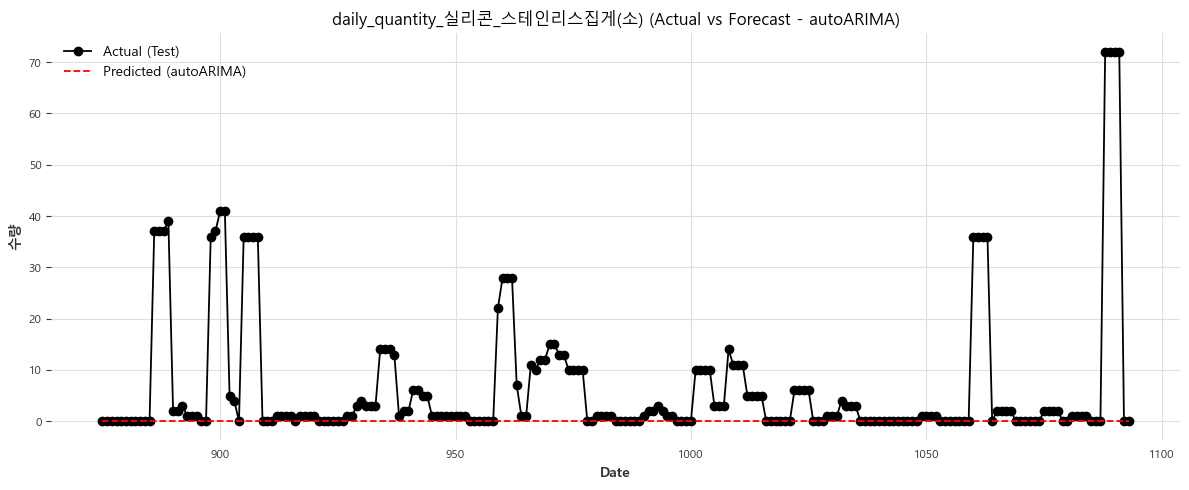

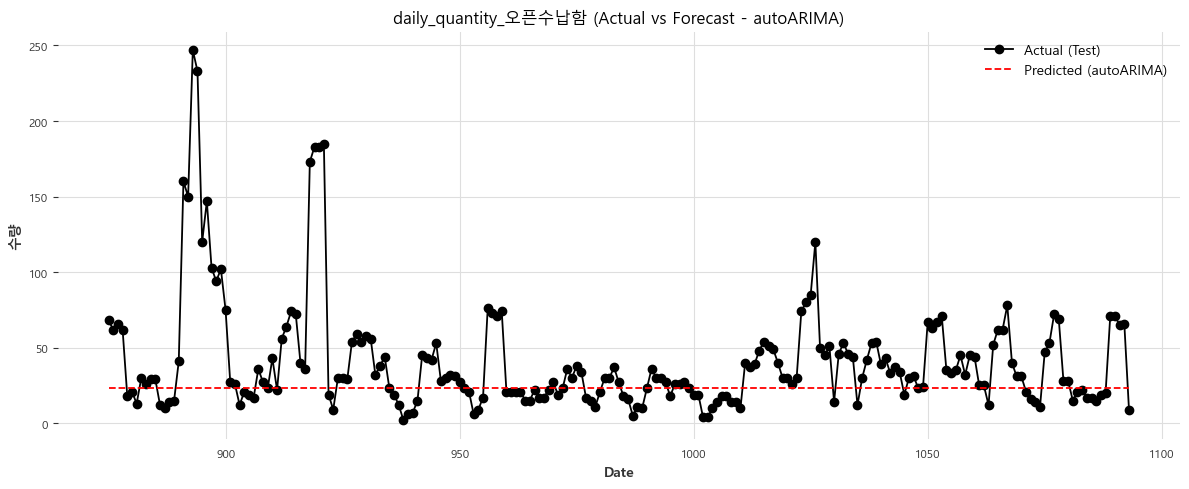

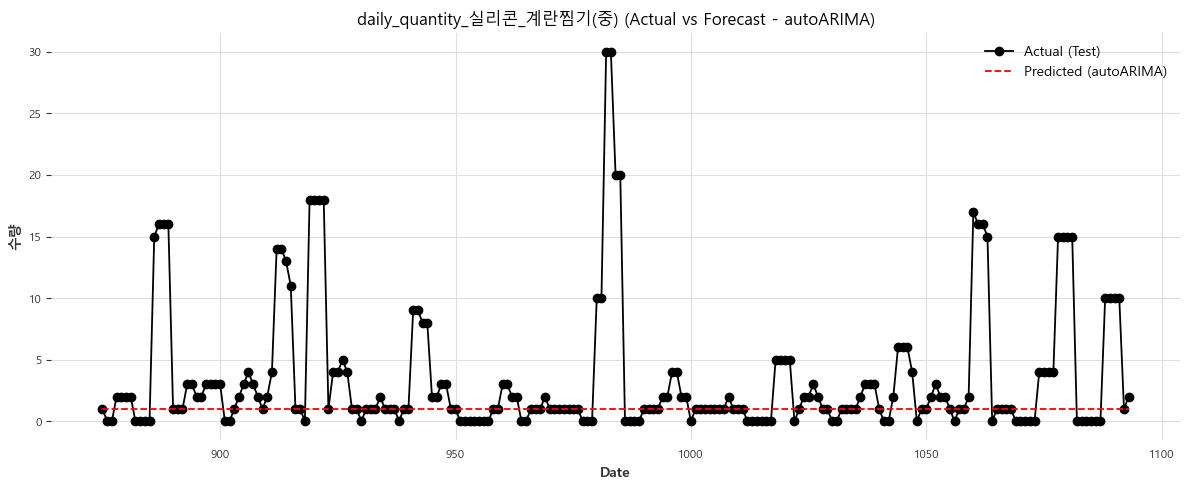

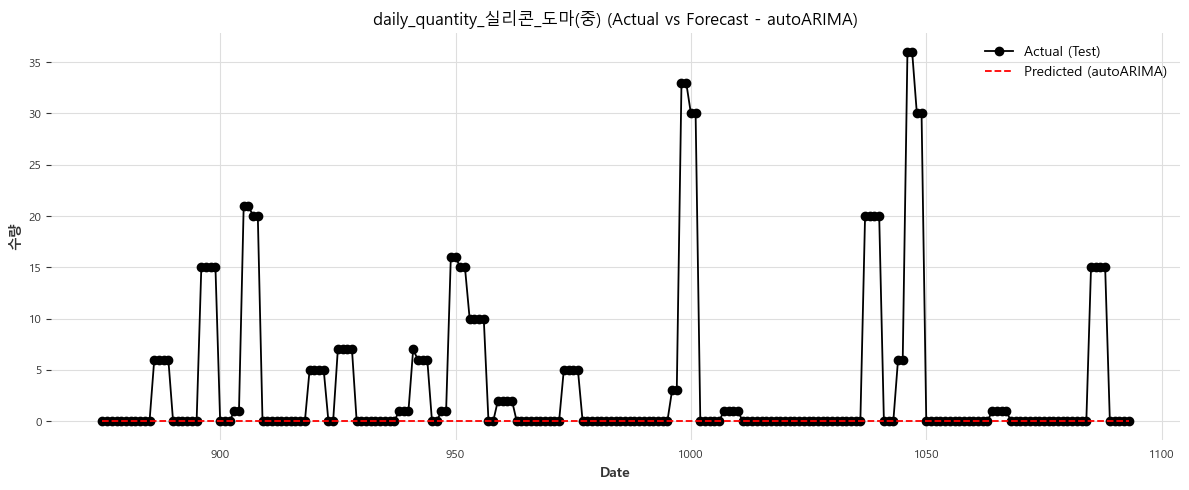

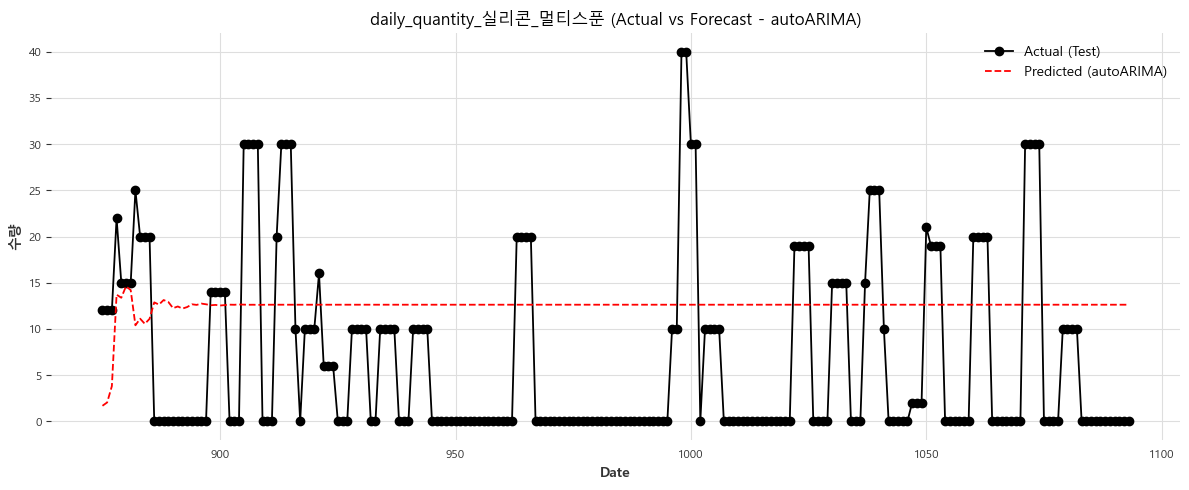

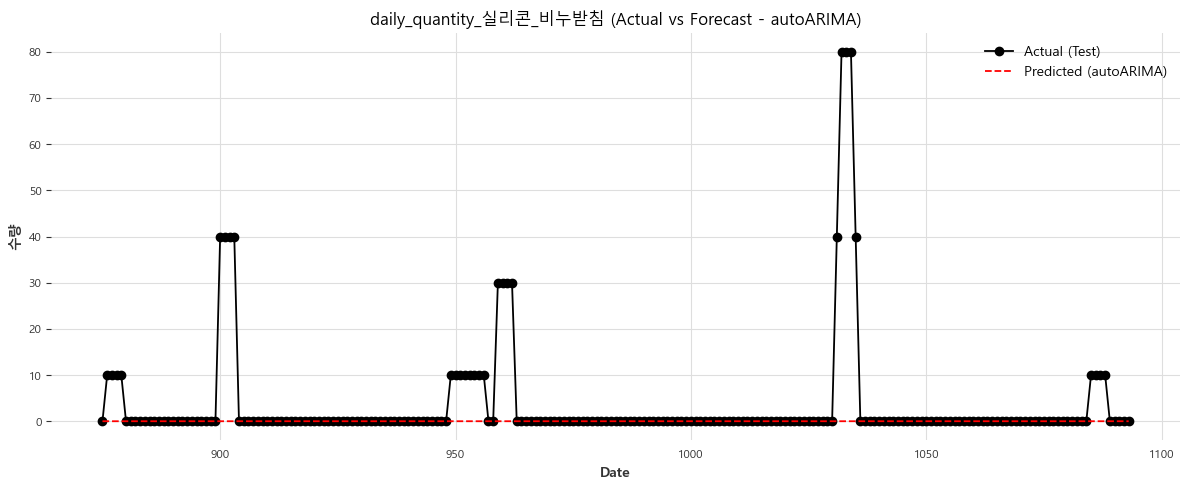

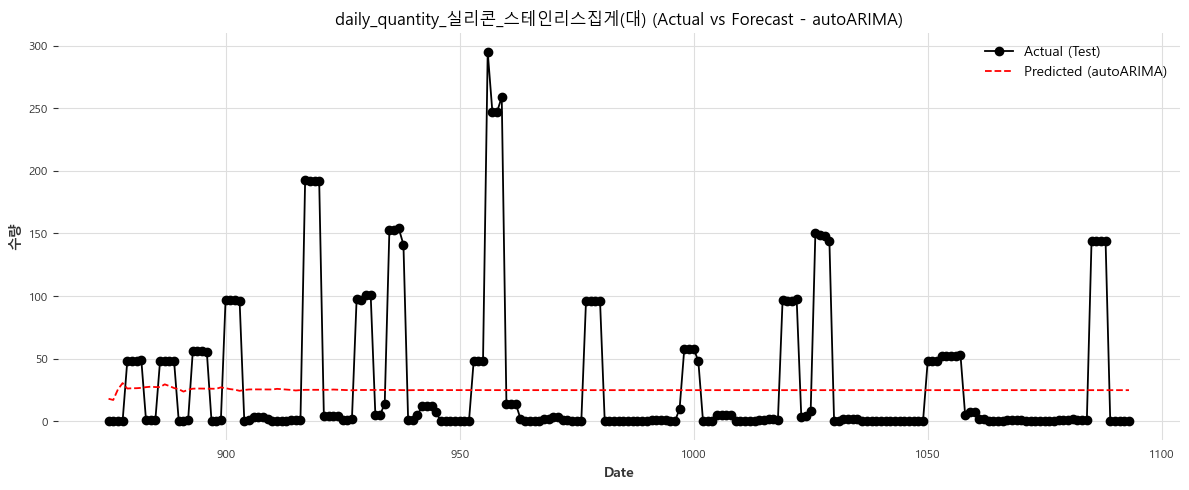

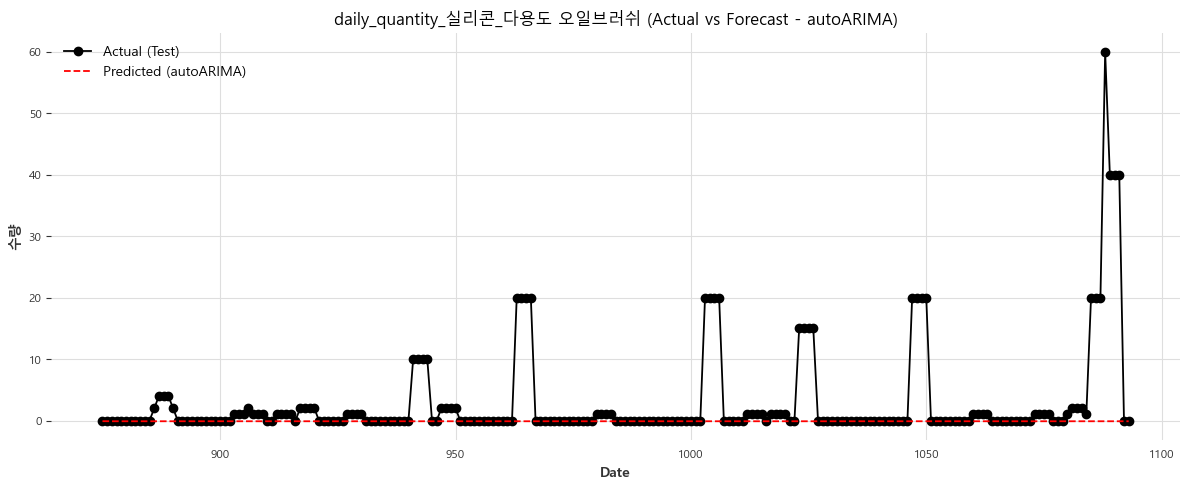

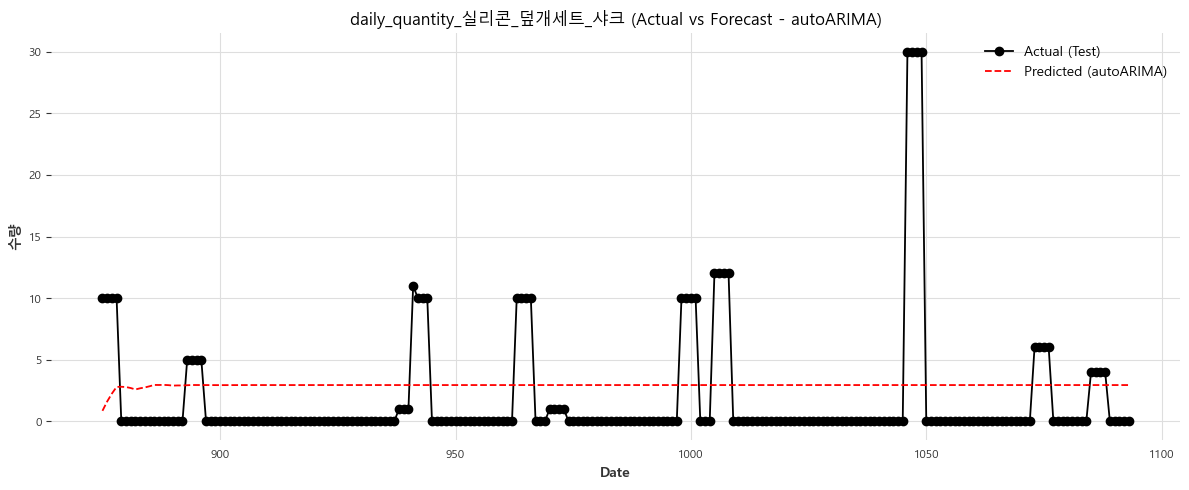

In [32]:
# 시각화
plot_autoarima_forecast(y_test_dict, y_pred_dict, test_df.index, target_cols)

### 3-2. SARIMA

In [33]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [34]:
# 원본 df에서 날짜 인덱스 추출
date_index = df.index[split_index:]

# test_df에 날짜 인덱스 설정
test_df.index = date_index

### 모델링 및 시각화

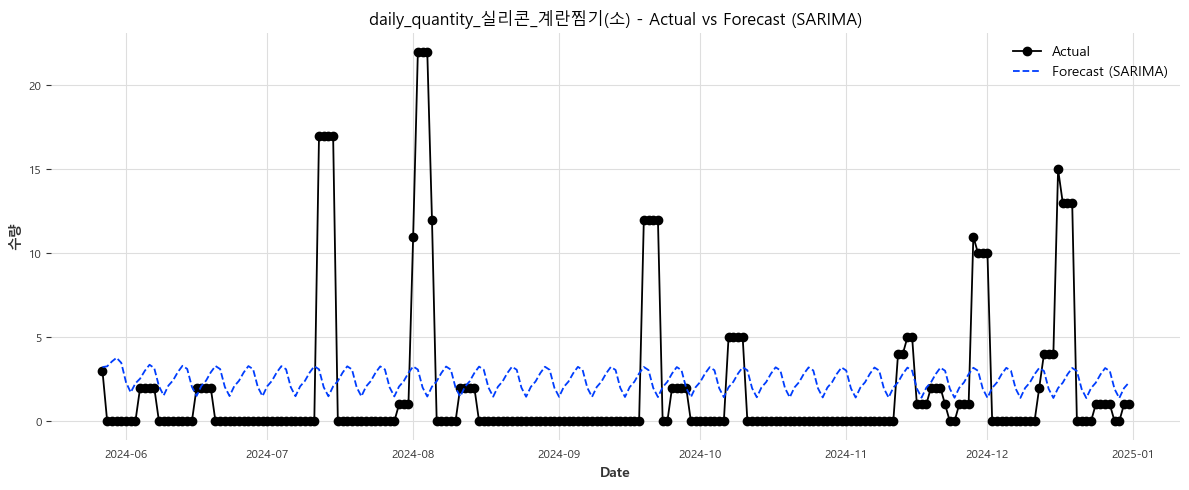

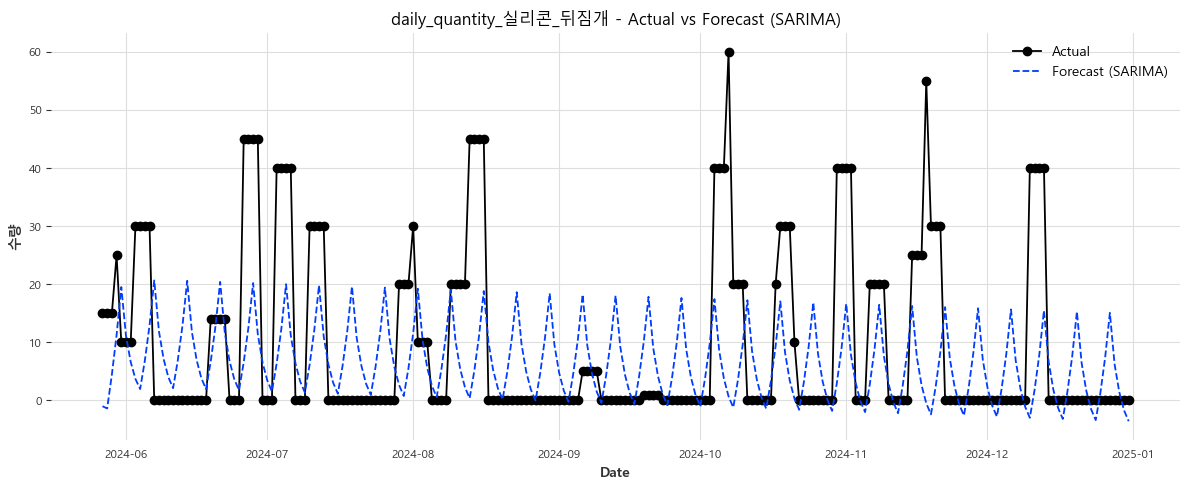

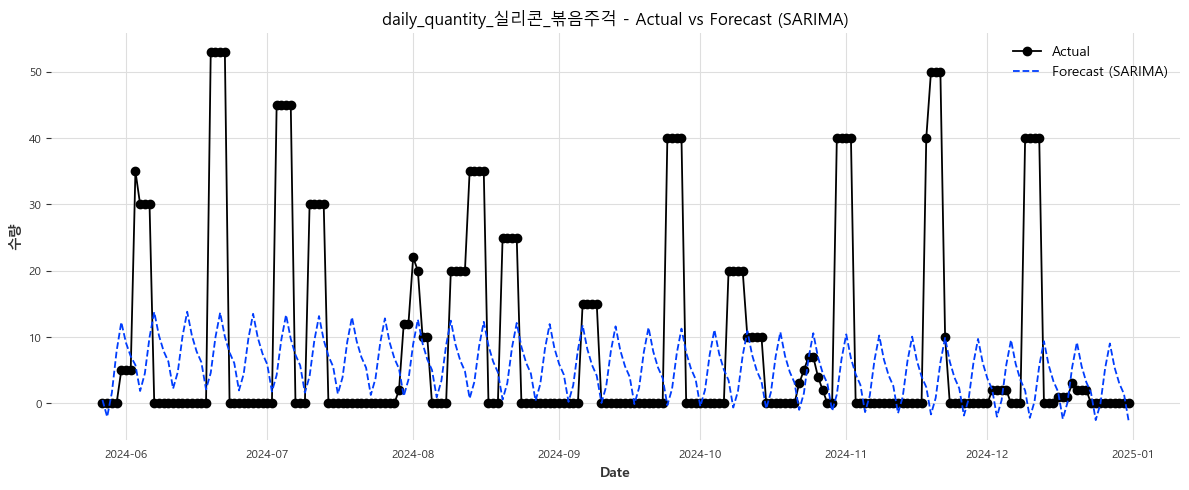

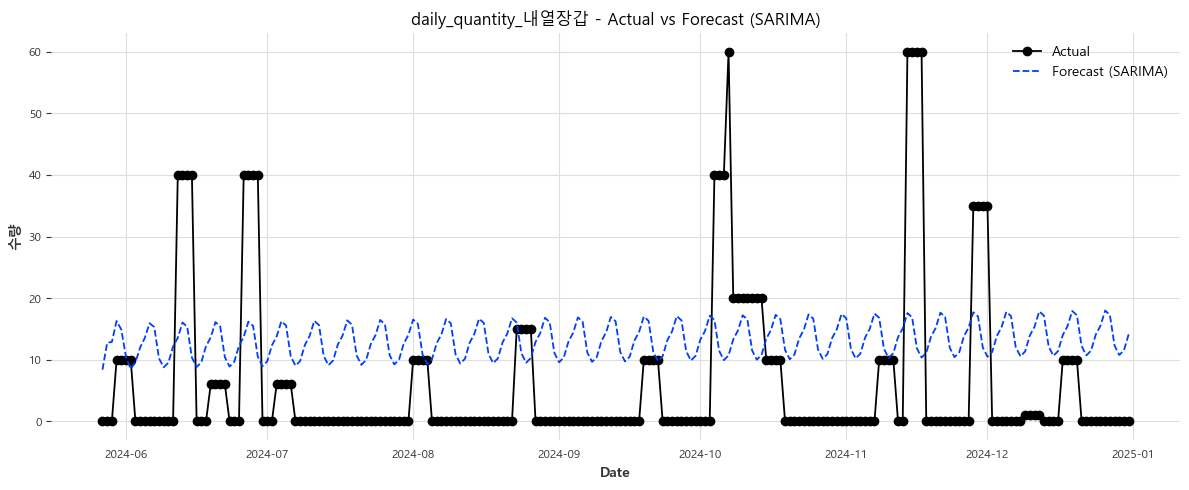

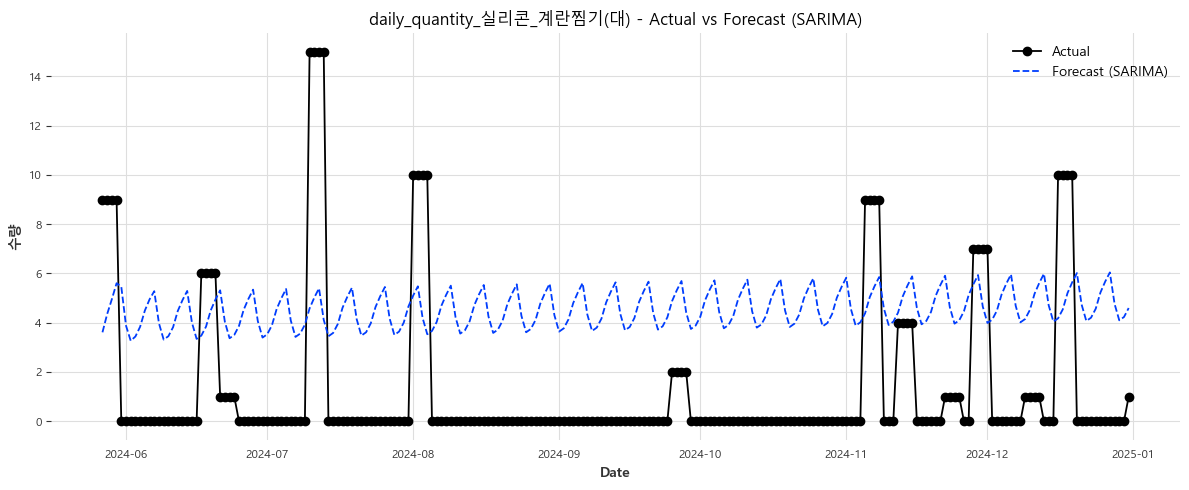

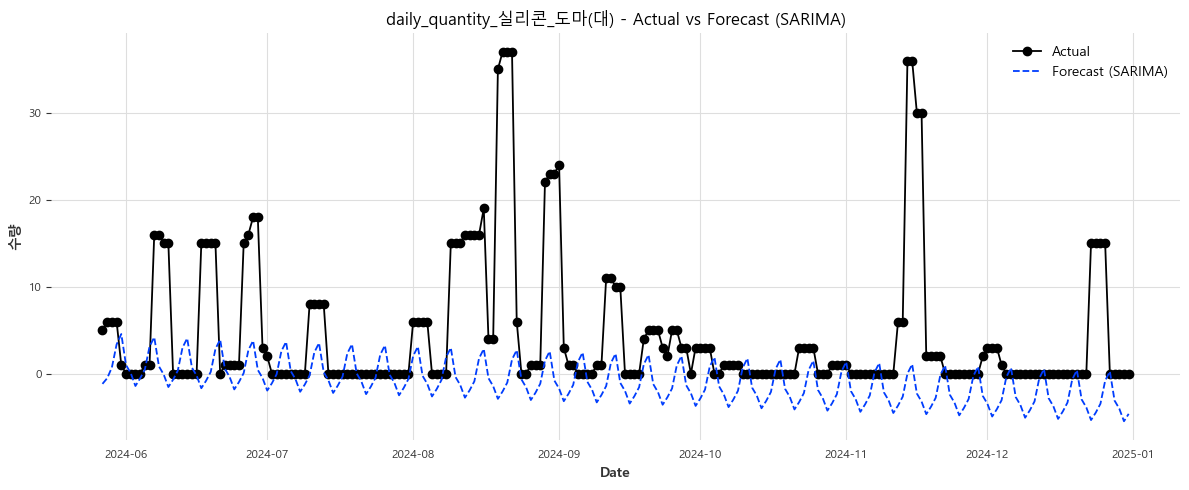

C:\Users\jwoo\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


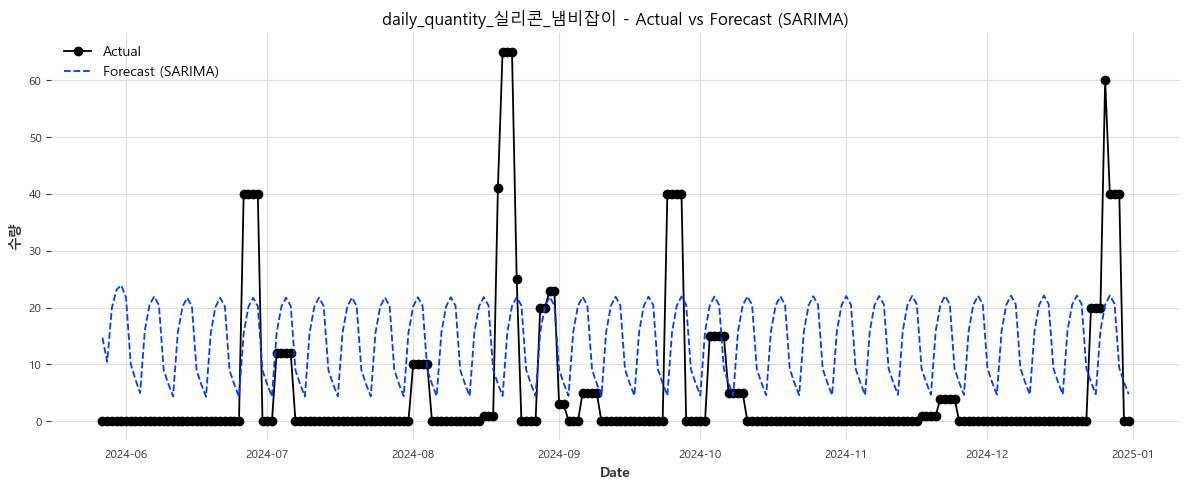

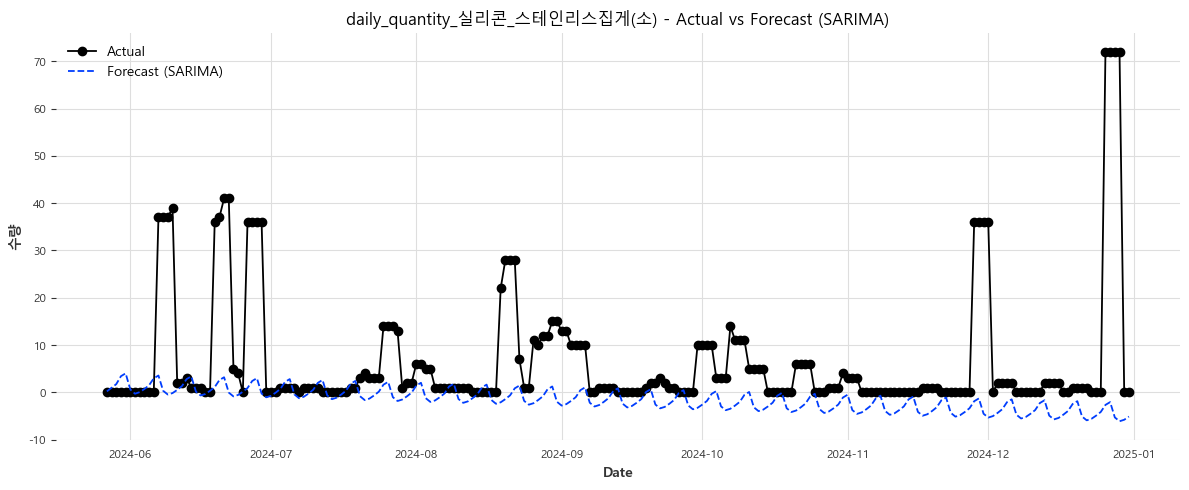

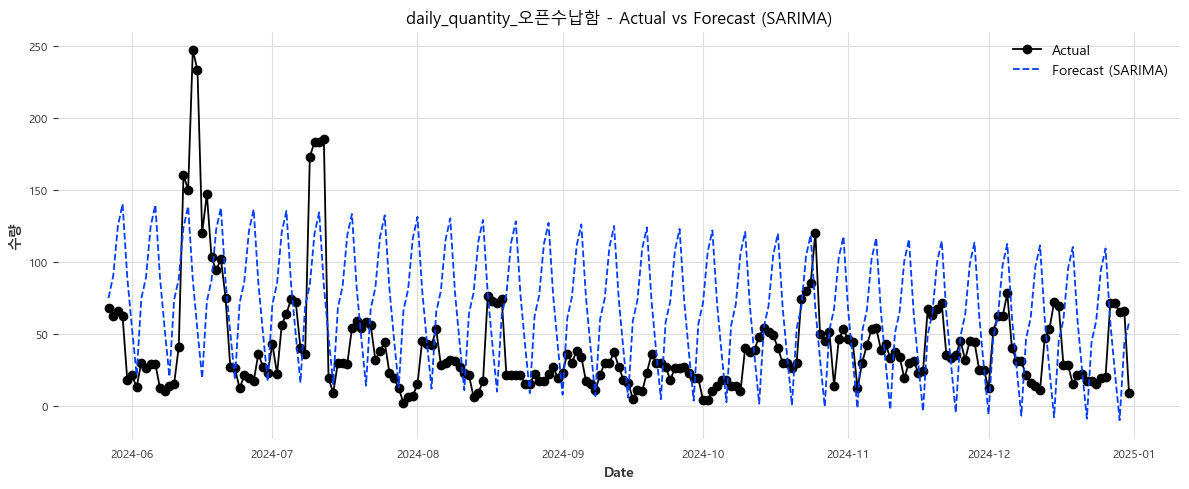

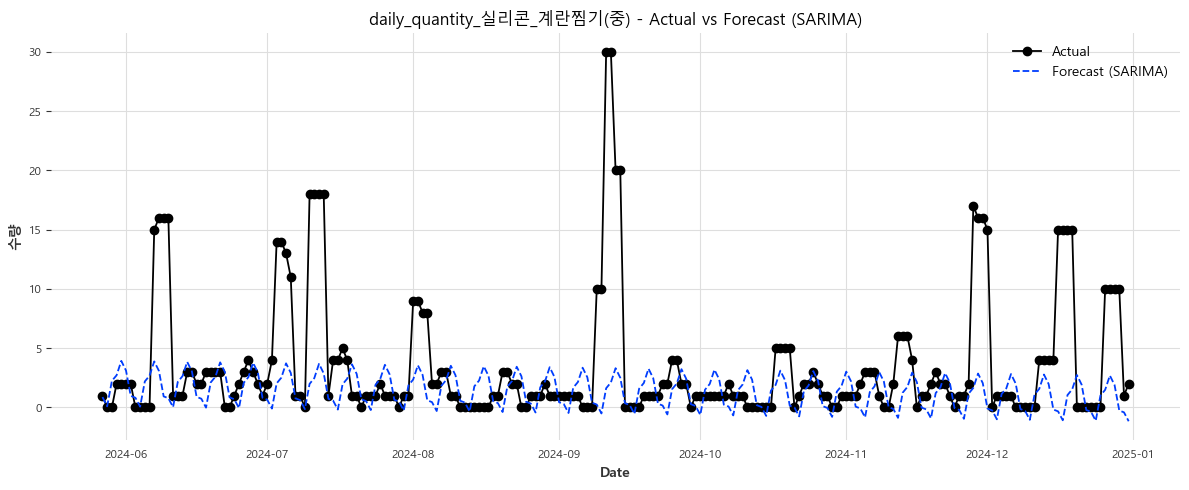

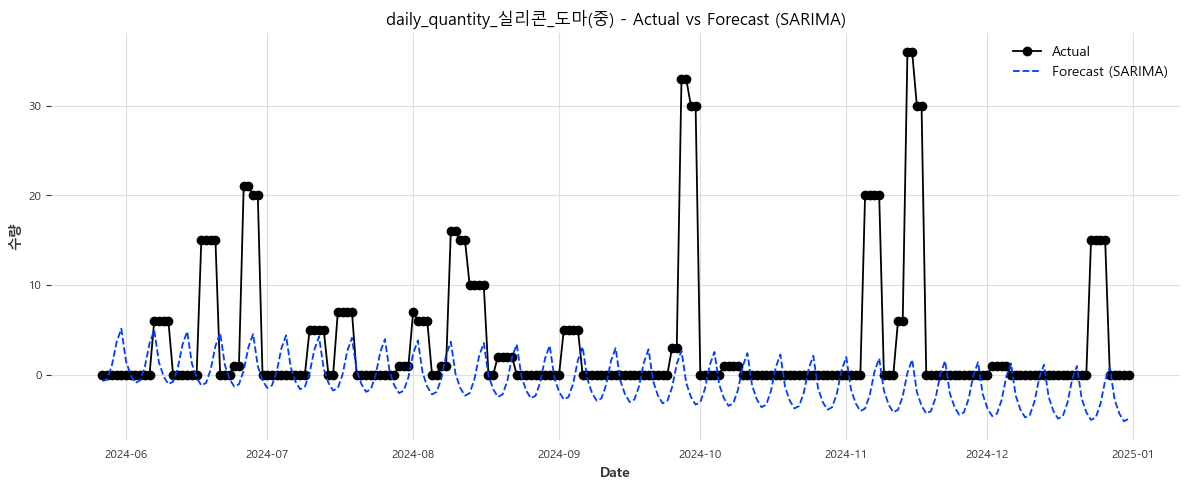

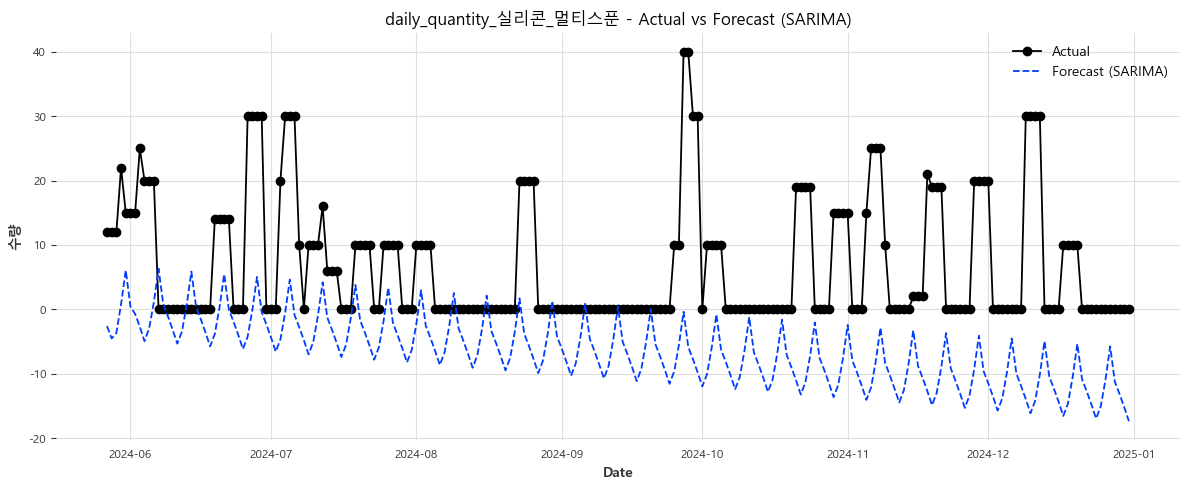

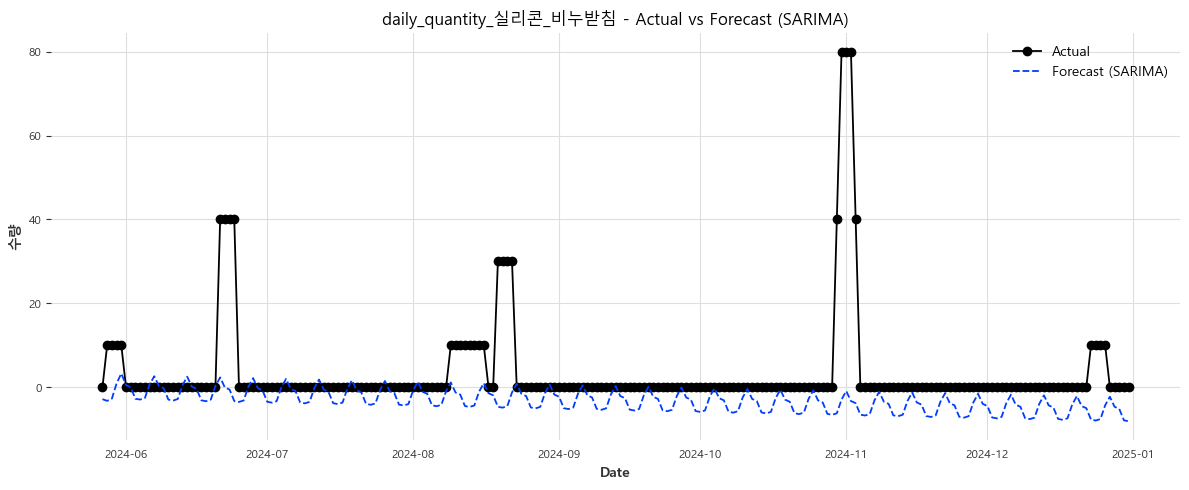

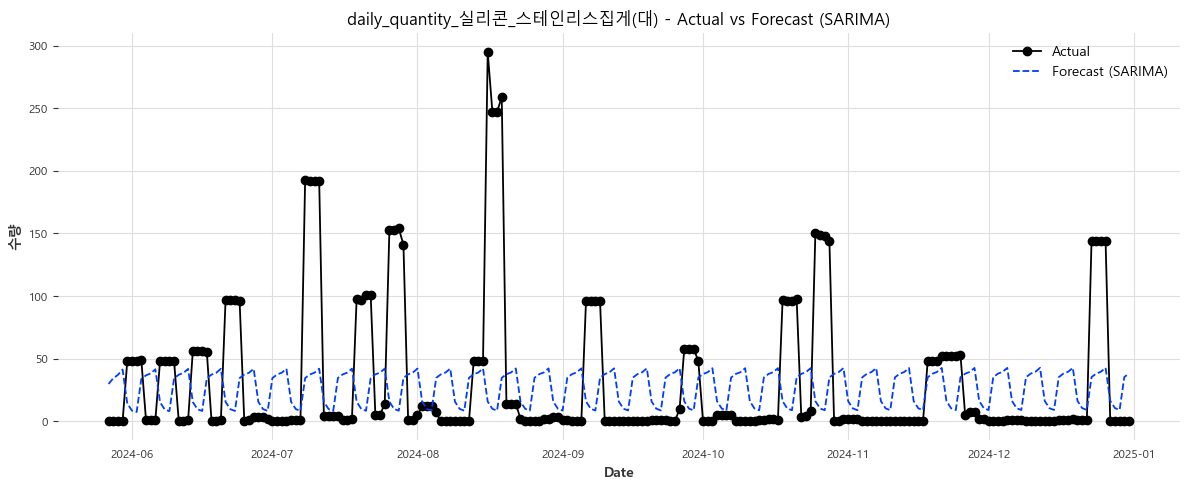

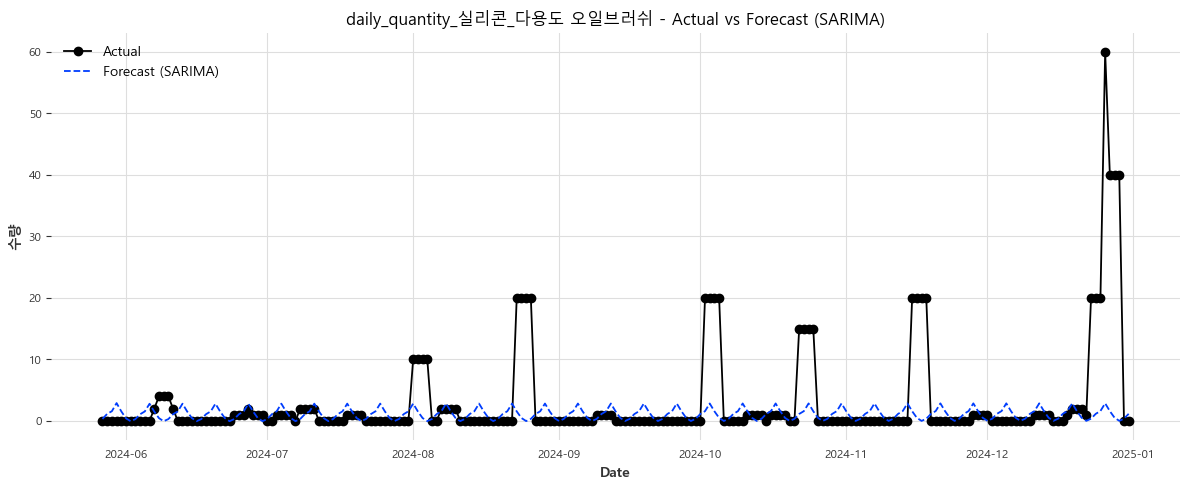

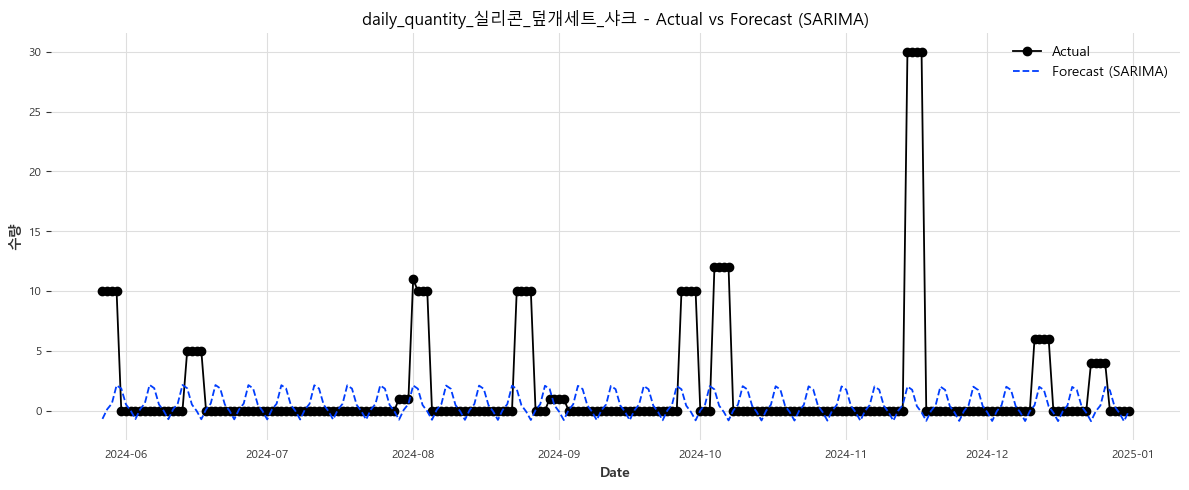

In [35]:
for col in target_cols:
    y_train = train_df[col]
    y_test = test_df[col]

    # SARIMA 모델 학습
    model = SARIMAX(y_train,
                    order=(1, 1, 1),           # ARIMA(p, d, q)
                    seasonal_order=(1, 1, 1, 7), # 계절성 (P, D, Q, m) # 일별 주기라면 m=7
                    enforce_stationarity=False,
                    enforce_invertibility=False)
    results = model.fit(disp=False)

    # 예측
    forecast = results.predict(start=len(y_train), end=len(y_train)+len(y_test)-1)

    # 시각화
    plt.figure(figsize=(12, 5))
    plt.plot(y_test.index, y_test, label='Actual', marker='o')
    plt.plot(y_test.index, forecast, label='Forecast (SARIMA)', linestyle='--')
    plt.title(f'{col} - Actual vs Forecast (SARIMA)')
    
    plt.xlabel('Date')
    plt.ylabel('수량')
    plt.grid(True)
    plt.legend()
    plt.xticks()
    plt.tight_layout()
    plt.show()

# 4. Croston

In [36]:
def croston_forecast_evaluate(train_df, test_df, col):
    train_y = train_df[col].values
    test_y = test_df[col].values

    # Croston 예측 (미래에 예측할 기간: test set 길이만큼 / Croston의 기본 버전 사용)
    # train_y를 학습하고, test_y 길이만큼 미래 예측, 'original'은 Croston의 가장 기본 버전
    fit_pred = croston.fit_croston(train_y, len(test_y), 'original')  # 공식 문서 참고

    # test 기간에 해당하는 예측값들을 배열로 받음
    croston_forecast = fit_pred['croston_forecast']

    # 평가 지표 계산
    rmse = np.sqrt(mean_squared_error(test_y, croston_forecast))
    mae = mean_absolute_error(test_y, croston_forecast)

    # Naive 모델 (이전값 그대로)
    naive_forecast = train_df[col].shift(1).dropna().values
    naive_actual = train_df[col][1:].values

    mase_denom = np.mean(np.abs(naive_actual - naive_forecast))
    rmsse_denom = np.sqrt(np.mean((naive_actual - naive_forecast) ** 2))

    mase = mae / mase_denom if mase_denom != 0 else np.nan
    rmsse = rmse / rmsse_denom if rmsse_denom != 0 else np.nan

    # 결과를 DataFrame으로 저장
    forecast_df = test_df[['date']].copy()
    forecast_df[f'forecast_{col}'] = croston_forecast

    return forecast_df, rmsse, mase

In [40]:
from tqdm import tqdm
from croston import croston

croston_forecasts = [] # 각 품목에 대한 예측 결과(DataFrame)를 리스트로 저장
croston_rmsse_results = {} # 품목별 RMSSE 점수를 저장하는 딕셔너리
croston_mase_results = {} # 품목별 MASE 점수를 저장하는 딕셔너리

for col in tqdm(target_cols):
    forecast, rmsse, mase = croston_forecast_evaluate(train_df, test_df, col)
    croston_forecasts.append(forecast)
    croston_rmsse_results[col] = rmsse
    croston_mase_results[col] = mase

100%|██████████████████████████████████████████████████████████████████████████████████| 16/16 [00:01<00:00,  9.37it/s]


In [41]:
# 각 지표에 대해 전체 평균값을 계산
avg_croston_rmsse = sum(croston_rmsse_results.values()) / len(croston_rmsse_results)
avg_croston_mase = sum(croston_mase_results.values()) / len(croston_mase_results)

# 전체적인 성능 출력
print("=== 전체 Croston_original 모델링 성능 ===")
print(f"전체 RMSSE 평균: {avg_croston_rmsse:.2f}")
print(f"전체 MASE 평균: {avg_croston_mase:.2f}")

=== 전체 Croston_original 모델링 성능 ===
전체 RMSSE 평균: 0.92
전체 MASE 평균: 2.45


In [54]:
croston_forecasts

[                 date  forecast_daily_quantity_실리콘_계란찜기(소)
 date                                                      
 2024-05-27 2024-05-27                             2.154185
 2024-05-28 2024-05-28                             2.154185
 2024-05-29 2024-05-29                             2.154185
 2024-05-30 2024-05-30                             2.154185
 2024-05-31 2024-05-31                             2.154185
 ...               ...                                  ...
 2024-12-27 2024-12-27                             2.154185
 2024-12-28 2024-12-28                             2.154185
 2024-12-29 2024-12-29                             2.154185
 2024-12-30 2024-12-30                             2.154185
 2024-12-31 2024-12-31                             2.154185
 
 [219 rows x 2 columns],
                  date  forecast_daily_quantity_실리콘_뒤짐개
 date                                                  
 2024-05-27 2024-05-27                        20.827338
 2024-05-28 2024-05-28   